In [1]:
import pandas as pd

print("Notebook restored successfully")

Notebook restored successfully


# What Makes a Society Healthy?

## Research Question

Which economic, social and health factors best explain differences in life expectancy across countries?

## Objective

The aim of this project is to investigate the determinants of life expectancy across countries using data from international organizations and machine learning techniques.

## Potential Determinants

### Economic Factors
- GDP per capita
- Healthcare expenditure

### Lifestyle Factors
- Obesity prevalence
- Smoking prevalence

### Environmental Factors
- Air pollution

### Social Factors
- Education

## Target Variable

Life expectancy at birth

## Project Roadmap

1. Data collection
2. Data cleaning
3. Exploratory data analysis
4. Feature selection
5. Machine learning models
6. Results interpretation
7. Conclusions

In [1]:
print("Project started")

Project started


In [2]:
import pandas as pd
import requests

def get_world_bank_indicator(indicator_code, indicator_name):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    
    params = {
        "format": "json",
        "per_page": 20000
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    records = data[1]
    df = pd.DataFrame(records)
    
    df = df[["countryiso3code", "country", "date", "value"]]
    df["country"] = df["country"].apply(lambda x: x["value"])
    
    df = df.rename(columns={
        "countryiso3code": "country_code",
        "date": "year",
        "value": indicator_name
    })
    
    df["year"] = df["year"].astype(int)
    
    return df

life_expectancy = get_world_bank_indicator("SP.DYN.LE00.IN", "life_expectancy")
gdp_per_capita = get_world_bank_indicator("NY.GDP.PCAP.CD", "gdp_per_capita")

print(life_expectancy.head())
print(gdp_per_capita.head())

  country_code                      country  year  life_expectancy
0          AFE  Africa Eastern and Southern  2025              NaN
1          AFE  Africa Eastern and Southern  2024        65.349930
2          AFE  Africa Eastern and Southern  2023        65.146228
3          AFE  Africa Eastern and Southern  2022        64.487152
4          AFE  Africa Eastern and Southern  2021        62.979999
  country_code                      country  year  gdp_per_capita
0          AFE  Africa Eastern and Southern  2025             NaN
1          AFE  Africa Eastern and Southern  2024     1615.396356
2          AFE  Africa Eastern and Southern  2023     1571.449189
3          AFE  Africa Eastern and Southern  2022     1679.327622
4          AFE  Africa Eastern and Southern  2021     1562.416175


In [3]:
df = life_expectancy.merge(
    gdp_per_capita,
    on=["country_code", "country", "year"],
    how="inner"
)

df_2022 = df[df["year"] == 2022].dropna()

print(df_2022.shape)

df_2022.head()

(257, 5)


,country_code,country,year,life_expectancy,gdp_per_capita
3,AFE,Africa Eastern and Southern,2022,64.487152,1679.327622
69,AFW,Africa Western and Central,2022,57.987850,2138.473153
135,ARB,Arab World,2022,71.876096,7950.355820
201,CSS,Caribbean small states,2022,72.832292,17456.308485
267,CEB,Central Europe and the Baltics,2022,76.652299,19530.155323


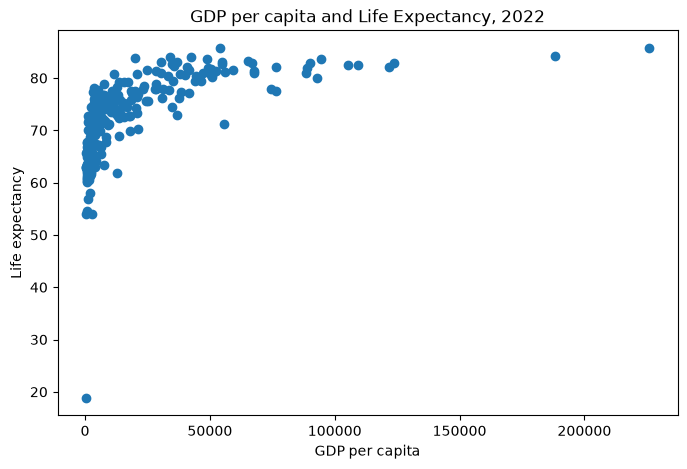

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df_2022["gdp_per_capita"], df_2022["life_expectancy"])
plt.xlabel("GDP per capita")
plt.ylabel("Life expectancy")
plt.title("GDP per capita and Life Expectancy, 2022")
plt.show()

In [6]:
correlation = df_2022["gdp_per_capita"].corr(df_2022["life_expectancy"])
print("Correlation:", correlation)

Correlation: 0.5805945069848593


## Preliminary Findings

A positive relationship exists between GDP per capita and life expectancy.

The correlation coefficient is approximately 0.58, suggesting that wealth is an important determinant of health outcomes, but does not fully explain differences in life expectancy across countries.

Additional social, economic and health-related variables will be incorporated in subsequent analyses.

In [4]:
print(df_2022.columns)

Index(['country_code', 'country', 'year', 'life_expectancy', 'gdp_per_capita'], dtype='str')


## Current Dataset

Variables currently included:

- Life expectancy (target variable)
- GDP per capita

Next variables to be added:

- Obesity prevalence
- Smoking prevalence
- Healthcare expenditure
- Air pollution

In [5]:
print(df_2022.describe())

         year  life_expectancy  gdp_per_capita
count   257.0       257.000000      257.000000
mean   2022.0        72.785004    19476.548373
std       0.0         7.637644    28996.961493
min    2022.0        18.818000      302.992505
25%    2022.0        67.675000     2536.400502
50%    2022.0        73.973000     7606.237525
75%    2022.0        77.817060    24387.038729
max    2022.0        85.746000   226052.001905


In [6]:
df_2022.nlargest(10, "life_expectancy")[["country", "life_expectancy"]]

,country,life_expectancy
11817,Monaco,85.746000
14061,San Marino,85.708000
10761,Liechtenstein,84.121951
3501,Andorra,84.016000
9705,Japan,83.996341
7791,French Polynesia,83.859000
8913,"Hong Kong SAR, China",83.660976
15645,Switzerland,83.604878
3897,Australia,83.200000
15051,Spain,83.134146


In [7]:
df_2022.nsmallest(10, "life_expectancy")[["country", "life_expectancy"]]

,country,life_expectancy
5679,Central African Republic,18.81800
14853,"Somalia, Fed. Rep.",53.93100
12741,Nigeria,54.07900
5745,Chad,54.52800
10563,Lesotho,56.81200
69,Africa Western and Central,57.98785
11289,Mali,60.03500
12675,Niger,60.39800
8583,Guinea,60.43200
4557,Benin,60.47500


In [8]:
df_2022[df_2022["country"] == "Central African Republic"]

,country_code,country,year,life_expectancy,gdp_per_capita
5679,CAF,Central African Republic,2022,18.818,467.359825


In [9]:
life_expectancy[
    life_expectancy["country"] == "Central African Republic"
].sort_values("year", ascending=False).head(10)

,country_code,country,year,life_expectancy
5676,CAF,Central African Republic,2025,NaN
5677,CAF,Central African Republic,2024,57.671
5678,CAF,Central African Republic,2023,57.408
5679,CAF,Central African Republic,2022,18.818
5680,CAF,Central African Republic,2021,40.279
5681,CAF,Central African Republic,2020,50.596
5682,CAF,Central African Republic,2019,31.530
5683,CAF,Central African Republic,2018,52.297
5684,CAF,Central African Republic,2017,45.231
5685,CAF,Central African Republic,2016,50.999


In [10]:
df_clean = df_2022[df_2022["life_expectancy"] > 40].copy()

In [11]:
print(df_clean.shape)

(256, 5)


## Data Quality Note

An inspection of the dataset revealed anomalous life expectancy values for some observations (e.g. Central African Republic).

To reduce the impact of obvious data quality issues, observations with life expectancy below 40 years were excluded from the analysis.

## Data Cleaning

The original dataset contained 257 observations.

A preliminary inspection identified one clearly anomalous observation with life expectancy below 40 years.

After removing this outlier, the cleaned dataset contains 256 observations.

In [12]:
health_exp = get_world_bank_indicator(
    "SH.XPD.CHEX.GD.ZS",
    "health_expenditure"
)

health_exp.head()

,country_code,country,year,health_expenditure
0,AFE,Africa Eastern and Southern,2025,NaN
1,AFE,Africa Eastern and Southern,2024,NaN
2,AFE,Africa Eastern and Southern,2023,5.540810
3,AFE,Africa Eastern and Southern,2022,5.559021
4,AFE,Africa Eastern and Southern,2021,5.942595


In [13]:
print(health_exp.columns)
print(health_exp.shape)

Index(['country_code', 'country', 'year', 'health_expenditure'], dtype='str')
(17556, 4)


In [14]:
df2 = df_clean.merge(
    health_exp,
    on=["country_code", "country", "year"],
    how="left"
)

print(df2.shape)
df2.head()

(256, 6)


,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure
0,AFE,Africa Eastern and Southern,2022,64.487152,1679.327622,5.559021
1,AFW,Africa Western and Central,2022,57.987850,2138.473153,4.174496
2,ARB,Arab World,2022,71.876096,7950.355820,4.665253
3,CSS,Caribbean small states,2022,72.832292,17456.308485,5.572640
4,CEB,Central Europe and the Baltics,2022,76.652299,19530.155323,7.015183


In [15]:
df2 = df2[df2["country_code"].str.len() == 3]

print(df2.shape)

(252, 6)


In [16]:
corr_gdp = df2["life_expectancy"].corr(df2["gdp_per_capita"])

corr_health = df2["life_expectancy"].corr(df2["health_expenditure"])

print("GDP correlation:", corr_gdp)
print("Health expenditure correlation:", corr_health)

GDP correlation: 0.6262220032614335
Health expenditure correlation: 0.27420228925814627


In [17]:
df_clean = df2.copy()

## Preliminary Findings

GDP per capita shows a relatively strong positive correlation with life expectancy (0.626).

Healthcare expenditure as a percentage of GDP shows a weaker positive correlation (0.274).

This suggests that national wealth may be more strongly associated with life expectancy than the share of economic resources allocated to healthcare.

Further variables will be added to better understand the determinants of health outcomes.

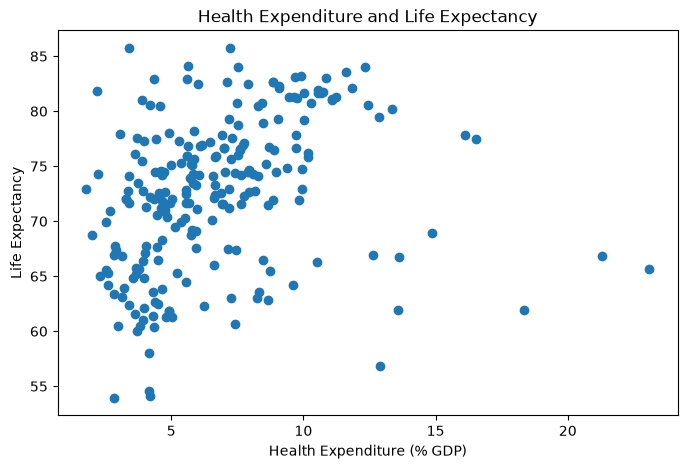

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(
    df2["health_expenditure"],
    df2["life_expectancy"]
)

plt.xlabel("Health Expenditure (% GDP)")
plt.ylabel("Life Expectancy")
plt.title("Health Expenditure and Life Expectancy")
plt.show()

## Interpretation

GDP per capita appears to be more strongly associated with life expectancy than healthcare expenditure as a percentage of GDP.

This may suggest that overall economic development influences health outcomes through multiple channels, including nutrition, education, infrastructure and access to healthcare.

Healthcare spending alone does not appear sufficient to explain cross-country differences in life expectancy.

## Next Variables

- Obesity prevalence
- Smoking prevalence
- Air pollution
- Education

# Dataset Expansion

The following variables will be incorporated into the analysis:

1. Obesity prevalence
2. Smoking prevalence
3. Air pollution
4. Education

The objective is to build a multi-factor model explaining differences in life expectancy across countries.

In [19]:
df_clean.to_csv("../data/life_expectancy_dataset_v1.csv", index=False)

print("Dataset v1 saved successfully")

Dataset v1 saved successfully


## Variable 3: Obesity Prevalence

Research Question:

Does obesity prevalence help explain differences in life expectancy across countries beyond economic factors?

In [20]:
print(df_clean.shape)
print(df_clean.columns)

(252, 6)
Index(['country_code', 'country', 'year', 'life_expectancy', 'gdp_per_capita',
       'health_expenditure'],
      dtype='str')


## Variable 3: Obesity Prevalence

Definition:
Percentage of adults classified as obese.

Expected relationship:
Higher obesity prevalence may be associated with lower life expectancy.

Reason for inclusion:
Obesity is a major global public health challenge and may help explain differences in health outcomes across countries.

In [21]:
df_clean.head()

,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure
0,AFE,Africa Eastern and Southern,2022,64.487152,1679.327622,5.559021
1,AFW,Africa Western and Central,2022,57.987850,2138.473153,4.174496
2,ARB,Arab World,2022,71.876096,7950.355820,4.665253
3,CSS,Caribbean small states,2022,72.832292,17456.308485,5.572640
4,CEB,Central Europe and the Baltics,2022,76.652299,19530.155323,7.015183


In [22]:
df_clean = df2[df2["country_code"].str.len() == 3].copy()

print(df_clean.shape)

(252, 6)


In [23]:
df_clean.head()

,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure
0,AFE,Africa Eastern and Southern,2022,64.487152,1679.327622,5.559021
1,AFW,Africa Western and Central,2022,57.987850,2138.473153,4.174496
2,ARB,Arab World,2022,71.876096,7950.355820,4.665253
3,CSS,Caribbean small states,2022,72.832292,17456.308485,5.572640
4,CEB,Central Europe and the Baltics,2022,76.652299,19530.155323,7.015183


In [24]:
aggregates = [
    "Africa",
    "Arab",
    "Europe",
    "Central Asia",
    "income",
    "states",
    "World",
    "OECD",
    "IDA",
    "IBRD",
    "Euro area"
]

df_clean = df2.copy()

for term in aggregates:
    df_clean = df_clean[
        ~df_clean["country"].str.contains(
            term,
            case=False,
            na=False
        )
    ]

print(df_clean.shape)

(212, 6)


In [25]:
df_clean.head(15)

,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure
5,EAR,Early-demographic dividend,2022,71.430455,4043.827763,4.780528
6,EAS,East Asia & Pacific,2022,76.676717,13139.210981,6.996939
14,FCS,Fragile and conflict affected situations,2022,62.702272,1850.917431,4.400807
15,HPC,Heavily indebted poor countries (HIPC),2022,63.840466,1121.483873,4.664174
22,LTE,Late-demographic dividend,2022,76.954367,12286.084681,6.165431
23,LCN,Latin America & Caribbean,2022,74.647210,9408.848202,7.954425
26,LDC,Least developed countries: UN classification,2022,65.763202,1299.361724,3.666332
34,NAC,North America,2022,77.817060,74535.636539,16.099456
38,PST,Post-demographic dividend,2022,80.192472,50969.801641,13.361814
39,PRE,Pre-demographic dividend,2022,61.383305,1770.155790,4.297327


In [26]:
air_pollution = get_world_bank_indicator(
    "EN.ATM.PM25.MC.M3",
    "air_pollution"
)

air_pollution.head()

,country_code,country,year,air_pollution
0,AFE,Africa Eastern and Southern,2025,NaN
1,AFE,Africa Eastern and Southern,2024,NaN
2,AFE,Africa Eastern and Southern,2023,NaN
3,AFE,Africa Eastern and Southern,2022,NaN
4,AFE,Africa Eastern and Southern,2021,NaN


In [27]:
air_pollution["air_pollution"].describe()

count    7688.000000
mean       28.390587
std        16.436362
min         4.895181
25%        16.755624
50%        23.958606
75%        39.223020
max       107.144665
Name: air_pollution, dtype: float64

In [28]:
air_pollution[
    air_pollution["year"] == 2022
]["air_pollution"].notna().sum()

np.int64(0)

## Variable Status

Included:
- GDP per capita
- Health expenditure

Pending:
- Obesity prevalence
- Smoking prevalence
- Education

Excluded:
- Air pollution (insufficient data availability for 2022)

# Phase 2: Lifestyle Factors

In [29]:
df_clean.to_csv(
    "../data/life_expectancy_dataset_v2.csv",
    index=False
)

print("Dataset v2 saved")

Dataset v2 saved


In [30]:
from sklearn.model_selection import train_test_split

features = df_clean[
    ["gdp_per_capita", "health_expenditure"]
]

target = df_clean["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(169, 2)
(43, 2)


In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [32]:
ml_data = df_clean[
    ["life_expectancy", "gdp_per_capita", "health_expenditure"]
].dropna()

print(ml_data.shape)
print(ml_data.isna().sum())

(191, 3)
life_expectancy       0
gdp_per_capita        0
health_expenditure    0
dtype: int64


In [33]:
features = ml_data[["gdp_per_capita", "health_expenditure"]]
target = ml_data["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(152, 2)
(39, 2)


In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [35]:
score = model.score(X_test, y_test)

print("R-squared:", score)

R-squared: 0.44656357236844146


In [36]:
coefficients = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": model.coef_
})

coefficients

,Variable,Coefficient
0,gdp_per_capita,0.000128
1,health_expenditure,0.154009


## First Machine Learning Model

A linear regression model was trained using GDP per capita and healthcare expenditure as predictors of life expectancy.

Model performance:

- R² ≈ 0.45

Interpretation:

The model explains approximately 45% of the variation in life expectancy across countries.

This suggests that economic development and healthcare spending are important determinants of health outcomes, but additional variables are required to better explain cross-country differences.

In [37]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head(10)

,Actual,Predicted
207,69.237000,70.553528
123,71.206000,71.149392
215,76.965854,73.281156
111,81.187805,77.335081
104,71.969000,71.521414
53,64.246000,70.230657
39,61.383305,70.246467
54,77.483000,72.621677
180,70.087000,70.540898
177,66.506000,70.197779


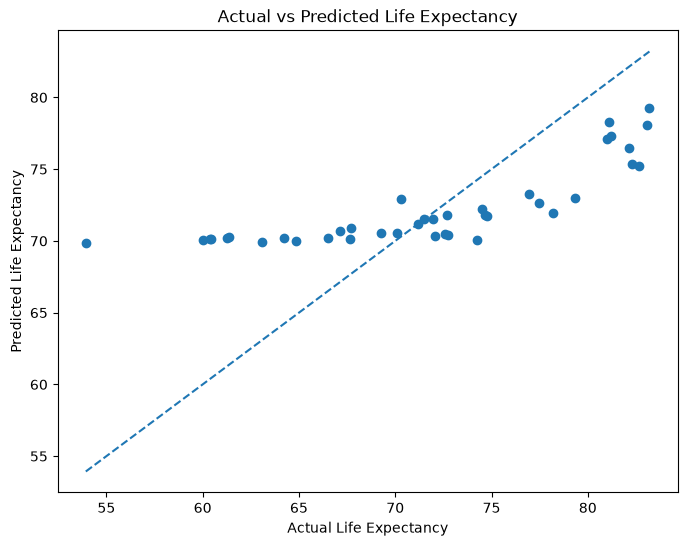

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## Model Evaluation

The linear regression model captures the general relationship between economic and health variables and life expectancy.

However, the model tends to underestimate countries with very high life expectancy and overestimate countries with very low life expectancy.

This suggests that additional explanatory variables are required to better capture cross-country differences in health outcomes.

In [39]:
ml_data.to_csv(
    "../data/ml_dataset_baseline.csv",
    index=False
)

print("Baseline ML dataset saved")

Baseline ML dataset saved


In [40]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 4.593884130300143


In [41]:
print(df_clean["year"].unique())

[2022]


## Baseline Model Results

Model:
- Linear Regression

Features:
- GDP per capita
- Health expenditure

Performance:
- R² = 0.447
- MAE = 4.59 years

Interpretation:
The model explains approximately 45% of the variation in life expectancy across countries and predicts life expectancy with an average error of about 4.6 years.

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_score = rf_model.score(X_test, y_test)

print("Random Forest R²:", rf_score)

Random Forest R²: 0.7522812893138838


In [43]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,gdp_per_capita,0.836723
1,health_expenditure,0.163277


In [ ]:
# Variable 5: Education

Research Question:

Does educational attainment help explain differences in life expectancy across countries beyond economic development?

Expected relationship:

Higher levels of education are associated with higher life expectancy.

Reason for inclusion:

Education influences health literacy, income opportunities, lifestyle choices and access to healthcare.

In [44]:
education = get_world_bank_indicator(
    "SE.SEC.CUAT.UP.ZS",
    "education"
)

education.head()

,country_code,country,year,education
0,AFE,Africa Eastern and Southern,2025,NaN
1,AFE,Africa Eastern and Southern,2024,NaN
2,AFE,Africa Eastern and Southern,2023,NaN
3,AFE,Africa Eastern and Southern,2022,NaN
4,AFE,Africa Eastern and Southern,2021,NaN


In [45]:
education["education"].describe()

count    2464.000000
mean       50.744699
std        25.917803
min         0.200000
25%        29.728954
50%        51.280480
75%        74.128016
max        98.383919
Name: education, dtype: float64

In [46]:
education[
    education["year"] == 2022
]["education"].notna().sum()

np.int64(115)

In [47]:
df_edu = df_clean.merge(
    education,
    on=["country_code", "country", "year"],
    how="left"
)

print(df_edu.shape)

df_edu.head()

(212, 7)


,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure,education
0,EAR,Early-demographic dividend,2022,71.430455,4043.827763,4.780528,NaN
1,EAS,East Asia & Pacific,2022,76.676717,13139.210981,6.996939,NaN
2,FCS,Fragile and conflict affected situations,2022,62.702272,1850.917431,4.400807,NaN
3,HPC,Heavily indebted poor countries (HIPC),2022,63.840466,1121.483873,4.664174,NaN
4,LTE,Late-demographic dividend,2022,76.954367,12286.084681,6.165431,NaN


In [48]:
ml_data_edu = df_edu[
    [
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure",
        "education"
    ]
].dropna()

print(ml_data_edu.shape)

(107, 4)


In [49]:
features = ml_data_edu[
    [
        "gdp_per_capita",
        "health_expenditure",
        "education"
    ]
]

target = ml_data_edu["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_score = rf_model.score(X_test, y_test)

print("Random Forest R²:", rf_score)

Random Forest R²: 0.6305248785636206


# Variable 6: Obesity Prevalence

Research Question:

Does obesity prevalence improve the prediction of life expectancy beyond economic and healthcare variables?

Expected relationship:

Higher obesity prevalence may be associated with lower life expectancy.

Reason for inclusion:

Obesity is one of the most important global risk factors affecting health outcomes.

# Project Status - Milestone 1

Dataset:
- Life Expectancy
- GDP per capita
- Health Expenditure

Observations:
- 191 countries/territories

Models:
- Linear Regression (R² ≈ 0.447)
- Random Forest (R² ≈ 0.752)

Key Finding:

GDP per capita is currently the dominant predictor of life expectancy.

Health expenditure contributes additional predictive power, but its importance is substantially lower than GDP.

Next Steps:

- Investigate obesity prevalence
- Investigate smoking prevalence
- Evaluate education indicators
- Rebuild and compare machine learning models

## Current Best Model

Random Forest

Features:
- GDP per capita
- Health expenditure

Performance:
- R² ≈ 0.752
- MAE ≈ 4.59

Feature Importance:
- GDP per capita ≈ 83.7%
- Health expenditure ≈ 16.3%

Research Question:

Can lifestyle variables improve predictive performance beyond economic variables?

In [50]:
baseline_r2 = 0.7522812893138838

print("Current benchmark R²:", baseline_r2)

Current benchmark R²: 0.7522812893138838


In [51]:
print("Countries in baseline dataset:", len(ml_data))
print("Countries in education dataset:", len(ml_data_edu))

Countries in baseline dataset: 191
Countries in education dataset: 107


## Education Variable Assessment

An education indicator was evaluated as a potential predictor of life expectancy.

However, including this variable reduced the sample size from 191 to 107 observations.

The resulting Random Forest model achieved a lower predictive performance (R² ≈ 0.63) compared to the baseline model (R² ≈ 0.75).

This suggests that data availability may limit the usefulness of this indicator in the current framework.

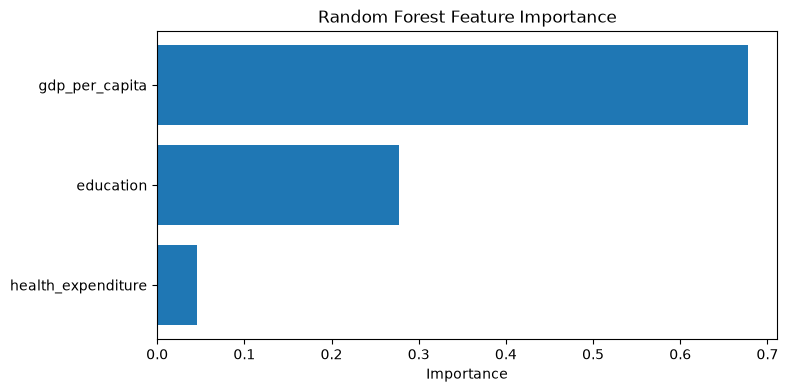

In [52]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,4))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()

In [53]:
ml_data.to_csv(
    "../data/best_model_dataset.csv",
    index=False
)

print("Best model dataset saved")

Best model dataset saved


In [54]:
ml_data.describe()

,life_expectancy,gdp_per_capita,health_expenditure
count,191.000000,191.000000,191.000000
mean,72.640516,18153.273812,6.783345
std,7.091703,29975.032726,3.377785
min,53.931000,302.992505,1.770422
25%,67.054500,2345.348921,4.309873
50%,73.503000,6571.974455,6.240941
75%,77.583305,20163.151297,8.527584
max,85.746000,226052.001905,23.088169


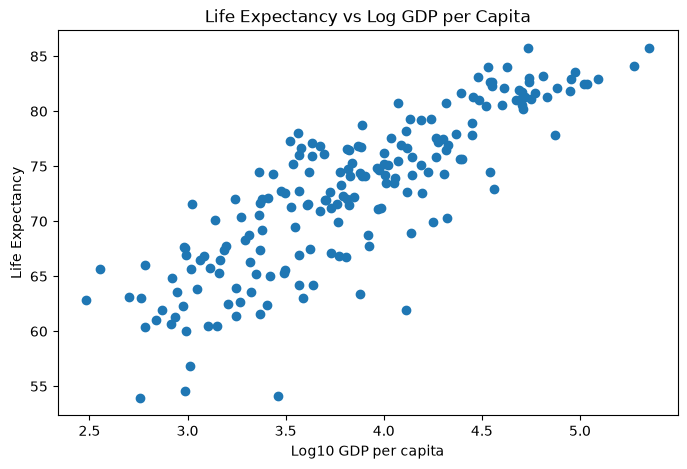

In [55]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    np.log10(ml_data["gdp_per_capita"]),
    ml_data["life_expectancy"]
)

plt.xlabel("Log10 GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy vs Log GDP per Capita")

plt.show()

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

ml_log = ml_data.copy()

ml_log["log_gdp"] = np.log10(
    ml_log["gdp_per_capita"]
)

features = ml_log[
    ["log_gdp", "health_expenditure"]
]

target = ml_log["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

log_model = LinearRegression()

log_model.fit(X_train, y_train)

print(
    "Log GDP Linear Regression R²:",
    log_model.score(X_test, y_test)
)

Log GDP Linear Regression R²: 0.788937897635052


## GDP, Education and Life Expectancy

### Logarithmic GDP Transformation

The relationship between GDP per capita and life expectancy appears substantially more linear after applying a logarithmic transformation to GDP.

This suggests the presence of diminishing returns to income: increases in GDP have a larger impact on life expectancy in lower-income countries and a smaller impact in wealthier countries.

### Model Performance

A linear regression model using:

- Log GDP per capita
- Health expenditure

achieved:

- R² ≈ 0.789

This represents a substantial improvement over the baseline linear model using untransformed GDP per capita and health expenditure (R² ≈ 0.447).

### Feature Importance Analysis

A Random Forest model including GDP per capita, health expenditure and education suggests that:

- GDP per capita remains the dominant predictor of life expectancy.
- Education emerges as the second most important variable when available.
- Health expenditure contributes relatively little additional predictive power.

### Key Insight

Economic development remains the strongest determinant of life expectancy in the current dataset.

However, educational attainment appears to provide substantial explanatory value beyond purely economic indicators.

The main limitation of the education variable is data availability, which reduces the usable sample size from 191 to 107 observations.

For this reason, education is treated as a promising but coverage-limited variable at this stage of the project.

# Variable 6: Obesity Prevalence

Research Question:

Does obesity prevalence improve the prediction of life expectancy beyond economic and healthcare variables?

Definition:

Obesity prevalence measures the percentage of adults aged 18 and older with a BMI of 30 kg/m² or higher.

Expected relationship:

Higher obesity prevalence may be associated with lower life expectancy.

Reason for inclusion:

Obesity is a major public health risk factor and may help explain differences in life expectancy between countries with similar levels of economic development.

In [57]:
obesity = get_world_bank_indicator(
    "WB_HCP_OBESITY",
    "obesity"
)

obesity.head()

IndexError: list index out of range

In [58]:
import pandas as pd

obesity_url = "https://data360files.worldbank.org/data360-data/data/WB_HCP/WB_HCP_OBESITY.csv"

obesity_raw = pd.read_csv(obesity_url)

obesity_raw.head()

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1028)>

In [59]:
import pandas as pd
import requests
from io import StringIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

obesity_url = "https://data360files.worldbank.org/data360-data/data/WB_HCP/WB_HCP_OBESITY.csv"

response = requests.get(obesity_url, verify=False)

print(response.status_code)
print(response.text[:500])

200
STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3,COMP_BREAKDOWN_3_LABEL,TIME_PERIOD,OBS_VALUE,DECIMALS,DECIMALS_LABEL,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CO


In [60]:
obesity_raw = pd.read_csv(StringIO(response.text))

print(obesity_raw.shape)
print(obesity_raw.columns)

obesity_raw.head()

(19404, 39)
Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'DECIMALS', 'DECIMALS_LABEL', 'DATABASE_ID',
       'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE',
       'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'OBS_STATUS',
       'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='str')


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,AFG,Afghanistan,WB_HCP_OBESITY,Prevalence of obesity among adults (%),_T,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,AFG,Afghanistan,WB_HCP_OBESITY,Prevalence of obesity among adults (%),M,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,AFG,Afghanistan,WB_HCP_OBESITY,Prevalence of obesity among adults (%),F,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,AFG,Afghanistan,WB_HCP_OBESITY,Prevalence of obesity among adults (%),_T,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,AFG,Afghanistan,WB_HCP_OBESITY,Prevalence of obesity among adults (%),M,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public


In [61]:
print(obesity_raw.columns.tolist())

['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'DECIMALS', 'DECIMALS_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']


In [62]:
obesity_raw[[
    "REF_AREA",
    "REF_AREA_LABEL",
    "SEX",
    "SEX_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE"
]].head(20)

,REF_AREA,REF_AREA_LABEL,SEX,SEX_LABEL,TIME_PERIOD,OBS_VALUE
0,AFG,Afghanistan,_T,Total,1990,1.949513
1,AFG,Afghanistan,M,Male,1990,1.771799
2,AFG,Afghanistan,F,Female,1990,2.121754
3,AFG,Afghanistan,_T,Total,1991,2.105035
4,AFG,Afghanistan,M,Male,1991,1.905890
5,AFG,Afghanistan,F,Female,1991,2.296296
6,AFG,Afghanistan,_T,Total,1992,2.273393
7,AFG,Afghanistan,M,Male,1992,2.050795
8,AFG,Afghanistan,F,Female,1992,2.485387
9,AFG,Afghanistan,_T,Total,1993,2.455492


In [63]:
obesity = obesity_raw[
    obesity_raw["SEX"] == "_T"
][[
    "REF_AREA",
    "REF_AREA_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE"
]].copy()

obesity = obesity.rename(columns={
    "REF_AREA": "country_code",
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "obesity"
})

obesity["year"] = obesity["year"].astype(int)
obesity["obesity"] = pd.to_numeric(obesity["obesity"], errors="coerce")

obesity_2022 = obesity[obesity["year"] == 2022]

print(obesity_2022.shape)
print("Non-missing obesity values in 2022:", obesity_2022["obesity"].notna().sum())

obesity_2022.head()

(196, 4)
Non-missing obesity values in 2022: 196


,country_code,country,year,obesity
96,AFG,Afghanistan,2022,19.222592
195,AGO,Angola,2022,11.473734
294,ALB,Albania,2022,23.360185
393,AND,Andorra,2022,18.099177
492,ARE,United Arab Emirates,2022,32.079220


In [64]:
df_obesity = df_clean.merge(
    obesity_2022[["country_code", "year", "obesity"]],
    on=["country_code", "year"],
    how="left"
)

print(df_obesity.shape)
print("Non-missing obesity after merge:", df_obesity["obesity"].notna().sum())

df_obesity.head()

(212, 7)
Non-missing obesity after merge: 183


,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure,obesity
0,EAR,Early-demographic dividend,2022,71.430455,4043.827763,4.780528,NaN
1,EAS,East Asia & Pacific,2022,76.676717,13139.210981,6.996939,NaN
2,FCS,Fragile and conflict affected situations,2022,62.702272,1850.917431,4.400807,NaN
3,HPC,Heavily indebted poor countries (HIPC),2022,63.840466,1121.483873,4.664174,NaN
4,LTE,Late-demographic dividend,2022,76.954367,12286.084681,6.165431,NaN


In [65]:
print("Non-missing obesity after merge:", df_obesity["obesity"].notna().sum())

Non-missing obesity after merge: 183


In [66]:
ml_data_obesity = df_obesity[
    [
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure",
        "obesity"
    ]
].dropna()

print(ml_data_obesity.shape)

(177, 4)


In [67]:
features = ml_data_obesity[
    [
        "gdp_per_capita",
        "health_expenditure",
        "obesity"
    ]
]

target = ml_data_obesity["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

rf_model_obesity = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model_obesity.fit(X_train, y_train)

rf_score_obesity = rf_model_obesity.score(X_test, y_test)

print("Random Forest + Obesity R²:", rf_score_obesity)

Random Forest + Obesity R²: 0.7507111127931122


In [68]:
importance_obesity = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model_obesity.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance_obesity

,Feature,Importance
0,gdp_per_capita,0.812669
1,health_expenditure,0.094637
2,obesity,0.092694


In [69]:
importance_obesity = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model_obesity.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance_obesity

,Feature,Importance
0,gdp_per_capita,0.812669
1,health_expenditure,0.094637
2,obesity,0.092694


## Obesity Prevalence Assessment

Obesity prevalence was added as the first lifestyle-related variable.

Dataset after adding obesity:
- 177 observations
- Features: GDP per capita, health expenditure, obesity prevalence

Model:
- Random Forest Regressor

Performance:
- Baseline Random Forest R² ≈ 0.752
- Random Forest with obesity R² ≈ 0.751

Interpretation:

Adding obesity prevalence did not improve predictive performance compared to the baseline Random Forest model.

This suggests that, in the current cross-country dataset, obesity prevalence does not add substantial predictive information beyond GDP per capita and health expenditure.

However, obesity remains conceptually relevant as a public health variable and may still be useful in descriptive analysis or in combination with other lifestyle indicators such as smoking.

## Obesity Feature Importance

After adding obesity prevalence, the Random Forest model achieved an R² of approximately 0.751, which is almost identical to the baseline Random Forest model (R² ≈ 0.752).

Feature importance results show that GDP per capita remains the dominant predictor of life expectancy.

However, obesity prevalence has a non-negligible importance, similar to health expenditure.

Feature importance:
- GDP per capita: ≈ 81.3%
- Health expenditure: ≈ 9.5%
- Obesity prevalence: ≈ 9.3%

Interpretation:

Although obesity prevalence does not improve the overall predictive performance of the model, it appears to contribute some explanatory information.

This suggests that lifestyle-related factors may be relevant, but their impact is smaller than economic development in the current cross-country dataset.

# Variable 7: Smoking Prevalence

Research Question:

Does smoking prevalence improve the prediction of life expectancy beyond economic, healthcare and obesity-related variables?

Definition:

Smoking prevalence measures the percentage of adults who currently use tobacco products.

Expected relationship:

Higher smoking prevalence may be associated with lower life expectancy.

Reason for inclusion:

Smoking is one of the major preventable risk factors affecting health outcomes and mortality.

In [70]:
smoking = get_world_bank_indicator(
    "SH.PRV.SMOK",
    "smoking"
)

smoking.head()

,country_code,country,year,smoking
0,AFE,Africa Eastern and Southern,2025,NaN
1,AFE,Africa Eastern and Southern,2024,NaN
2,AFE,Africa Eastern and Southern,2023,NaN
3,AFE,Africa Eastern and Southern,2022,11.881951
4,AFE,Africa Eastern and Southern,2021,12.160833


In [71]:
print(smoking["smoking"].describe())

smoking_2022 = smoking[smoking["year"] == 2022]

print("Smoking observations in 2022:", smoking_2022["smoking"].notna().sum())

smoking_2022.head()

count    1688.000000
mean       23.954221
std        10.618336
min         3.300000
25%        15.400000
50%        23.600000
75%        30.900000
max        68.000000
Name: smoking, dtype: float64
Smoking observations in 2022: 211


,country_code,country,year,smoking
3,AFE,Africa Eastern and Southern,2022,11.881951
69,AFW,Africa Western and Central,2022,5.734154
135,ARB,Arab World,2022,20.332067
201,CSS,Caribbean small states,2022,NaN
267,CEB,Central Europe and the Baltics,2022,28.748376


In [72]:
df_smoking = df_obesity.merge(
    smoking_2022[["country_code", "year", "smoking"]],
    on=["country_code", "year"],
    how="left"
)

print(df_smoking.shape)
print("Non-missing smoking after merge:", df_smoking["smoking"].notna().sum())

df_smoking.head()

(212, 8)
Non-missing smoking after merge: 167


,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure,obesity,smoking
0,EAR,Early-demographic dividend,2022,71.430455,4043.827763,4.780528,NaN,23.551846
1,EAS,East Asia & Pacific,2022,76.676717,13139.210981,6.996939,NaN,24.640445
2,FCS,Fragile and conflict affected situations,2022,62.702272,1850.917431,4.400807,NaN,13.670796
3,HPC,Heavily indebted poor countries (HIPC),2022,63.840466,1121.483873,4.664174,NaN,10.186410
4,LTE,Late-demographic dividend,2022,76.954367,12286.084681,6.165431,NaN,22.021937


In [73]:
ml_data_lifestyle = df_smoking[
    [
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure",
        "obesity",
        "smoking"
    ]
].dropna()

print(ml_data_lifestyle.shape)

(155, 5)


In [74]:
features = ml_data_lifestyle[
    [
        "gdp_per_capita",
        "health_expenditure",
        "obesity",
        "smoking"
    ]
]

target = ml_data_lifestyle["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

rf_model_lifestyle = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model_lifestyle.fit(X_train, y_train)

rf_score_lifestyle = rf_model_lifestyle.score(X_test, y_test)

print("Random Forest + Obesity + Smoking R²:", rf_score_lifestyle)

Random Forest + Obesity + Smoking R²: 0.8021699829544777


In [75]:
importance_lifestyle = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model_lifestyle.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance_lifestyle

,Feature,Importance
0,gdp_per_capita,0.783368
3,smoking,0.091802
1,health_expenditure,0.077739
2,obesity,0.047091


In [76]:
ml_data_lifestyle.to_csv(
    "../data/ml_dataset_lifestyle.csv",
    index=False
)

print("Lifestyle ML dataset saved")

Lifestyle ML dataset saved


In [77]:
from sklearn.metrics import mean_absolute_error

lifestyle_predictions = rf_model_lifestyle.predict(X_test)

lifestyle_mae = mean_absolute_error(y_test, lifestyle_predictions)

print("Lifestyle Model MAE:", lifestyle_mae)

Lifestyle Model MAE: 2.7420632022029876


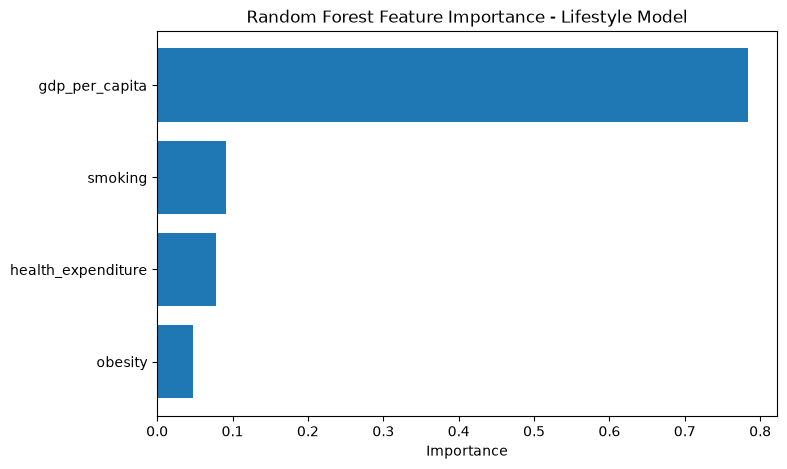

In [78]:
importance_lifestyle_plot = importance_lifestyle.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    importance_lifestyle_plot["Feature"],
    importance_lifestyle_plot["Importance"]
)

plt.title("Random Forest Feature Importance - Lifestyle Model")
plt.xlabel("Importance")

plt.show()

## Lifestyle Model: Obesity and Smoking

A lifestyle-augmented Random Forest model was trained by adding obesity prevalence and smoking prevalence to the baseline predictors.

### Model Comparison

Baseline Random Forest:

- Features: GDP per capita, health expenditure
- R² ≈ 0.752

Random Forest with obesity:

- Features: GDP per capita, health expenditure, obesity prevalence
- R² ≈ 0.751

Random Forest with obesity and smoking:

- Features: GDP per capita, health expenditure, obesity prevalence, smoking prevalence
- R² ≈ 0.802

### Feature Importance

The lifestyle model produced the following feature importance ranking:

- GDP per capita: ≈ 78.3%
- Smoking prevalence: ≈ 9.2%
- Health expenditure: ≈ 7.8%
- Obesity prevalence: ≈ 4.7%

### Interpretation

GDP per capita remains the dominant predictor of life expectancy.

However, adding smoking prevalence improves model performance, increasing R² from approximately 0.75 to approximately 0.80.

This suggests that lifestyle-related factors can provide additional predictive information beyond economic and healthcare variables.

Smoking prevalence appears to be more informative than obesity prevalence in the current dataset.

## Lifestyle Model Evaluation

The lifestyle-augmented Random Forest model achieved stronger predictive performance than the baseline model.

### Performance Comparison

Baseline Random Forest:

- Features: GDP per capita, health expenditure
- R² ≈ 0.752
- MAE ≈ 4.59 years

Lifestyle Random Forest:

- Features: GDP per capita, health expenditure, obesity prevalence, smoking prevalence
- R² ≈ 0.802
- MAE ≈ 2.74 years

### Interpretation

Adding lifestyle variables improved the model's predictive performance.

The R² increased from approximately 0.75 to approximately 0.80, while the mean absolute error decreased from around 4.6 years to around 2.7 years.

This suggests that lifestyle-related factors, particularly smoking prevalence, provide meaningful additional information beyond economic and healthcare variables.

GDP per capita remains the dominant predictor, but the inclusion of smoking and obesity helps the model better explain cross-country differences in life expectancy.

# Variable 8: Health Expenditure per Capita

Research Question:

Does health expenditure per capita improve the prediction of life expectancy compared to health expenditure as a share of GDP?

Definition:

Health expenditure per capita measures the average amount spent on healthcare per person.

Reason for inclusion:

Health expenditure as a percentage of GDP may not capture the absolute amount of healthcare resources available to individuals. Per capita spending may better reflect real healthcare access and system capacity.

In [79]:
health_exp_pc = get_world_bank_indicator(
    "SH.XPD.CHEX.PC.CD",
    "health_expenditure_per_capita"
)

health_exp_pc.head()

,country_code,country,year,health_expenditure_per_capita
0,AFE,Africa Eastern and Southern,2025,NaN
1,AFE,Africa Eastern and Southern,2024,NaN
2,AFE,Africa Eastern and Southern,2023,88.485585
3,AFE,Africa Eastern and Southern,2022,92.035288
4,AFE,Africa Eastern and Southern,2021,92.350333


In [80]:
print(health_exp_pc["health_expenditure_per_capita"].describe())

health_exp_pc_2022 = health_exp_pc[
    health_exp_pc["year"] == 2022
]

print(
    "Non-missing health expenditure per capita values in 2022:",
    health_exp_pc_2022["health_expenditure_per_capita"].notna().sum()
)

health_exp_pc_2022.head()

count     5713.000000
mean       973.114634
std       1758.592218
min          4.175786
25%         64.677567
50%        253.982468
75%        841.248840
max      13473.193359
Name: health_expenditure_per_capita, dtype: float64
Non-missing health expenditure per capita values in 2022: 239


,country_code,country,year,health_expenditure_per_capita
3,AFE,Africa Eastern and Southern,2022,92.035288
69,AFW,Africa Western and Central,2022,74.441253
135,ARB,Arab World,2022,348.767262
201,CSS,Caribbean small states,2022,915.955449
267,CEB,Central Europe and the Baltics,2022,1374.160069


In [81]:
df_final_test = df_smoking.merge(
    health_exp_pc_2022[
        ["country_code", "year", "health_expenditure_per_capita"]
    ],
    on=["country_code", "year"],
    how="left"
)

print(df_final_test.shape)
print(
    "Non-missing health expenditure per capita after merge:",
    df_final_test["health_expenditure_per_capita"].notna().sum()
)

df_final_test.head()

(212, 9)
Non-missing health expenditure per capita after merge: 191


,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure,obesity,smoking,health_expenditure_per_capita
0,EAR,Early-demographic dividend,2022,71.430455,4043.827763,4.780528,NaN,23.551846,191.392926
1,EAS,East Asia & Pacific,2022,76.676717,13139.210981,6.996939,NaN,24.640445,905.114819
2,FCS,Fragile and conflict affected situations,2022,62.702272,1850.917431,4.400807,NaN,13.670796,72.878151
3,HPC,Heavily indebted poor countries (HIPC),2022,63.840466,1121.483873,4.664174,NaN,10.186410,50.202795
4,LTE,Late-demographic dividend,2022,76.954367,12286.084681,6.165431,NaN,22.021937,757.780328


In [82]:
ml_data_final_test = df_final_test[
    [
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure_per_capita",
        "obesity",
        "smoking"
    ]
].dropna()

print(ml_data_final_test.shape)

(155, 5)


In [83]:
features = ml_data_final_test[
    [
        "gdp_per_capita",
        "health_expenditure_per_capita",
        "obesity",
        "smoking"
    ]
]

target = ml_data_final_test["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

rf_model_final_test = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model_final_test.fit(X_train, y_train)

rf_score_final_test = rf_model_final_test.score(X_test, y_test)

print("Random Forest with health expenditure per capita R²:", rf_score_final_test)

Random Forest with health expenditure per capita R²: 0.7868208299849164


In [84]:
final_test_predictions = rf_model_final_test.predict(X_test)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

print("Final test MAE:", final_test_mae)

Final test MAE: 2.7781426435877195


In [85]:
importance_final_test = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model_final_test.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance_final_test

,Feature,Importance
0,gdp_per_capita,0.643286
1,health_expenditure_per_capita,0.207787
3,smoking,0.098089
2,obesity,0.050838


## Health Expenditure per Capita Assessment

Health expenditure per capita was tested as an alternative to health expenditure as a percentage of GDP.

### Model Comparison

Lifestyle model:

- Features: GDP per capita, health expenditure (% GDP), obesity prevalence, smoking prevalence
- R² ≈ 0.802
- MAE ≈ 2.74 years

Per-capita health expenditure model:

- Features: GDP per capita, health expenditure per capita, obesity prevalence, smoking prevalence
- R² ≈ 0.787
- MAE ≈ 2.78 years

### Feature Importance

In the per-capita model, health expenditure per capita showed higher feature importance than health expenditure as a percentage of GDP.

Feature importance:
- GDP per capita: ≈ 64.3%
- Health expenditure per capita: ≈ 20.8%
- Smoking prevalence: ≈ 9.8%
- Obesity prevalence: ≈ 5.1%

### Interpretation

Health expenditure per capita is more informative than health expenditure as a percentage of GDP.

However, replacing health expenditure (% GDP) with health expenditure per capita did not improve overall predictive performance.

This may be because health expenditure per capita is strongly related to GDP per capita, reducing the amount of independent information it adds to the model.

For this reason, the previous lifestyle model remains the strongest candidate model at this stage.

In [86]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Log GDP Linear Regression",
        "Baseline Random Forest",
        "Random Forest + Education",
        "Random Forest + Obesity",
        "Lifestyle Random Forest",
        "Per-Capita Health Expenditure Random Forest"
    ],
    "Features": [
        "GDP per capita + Health expenditure (% GDP)",
        "Log GDP per capita + Health expenditure (% GDP)",
        "GDP per capita + Health expenditure (% GDP)",
        "GDP per capita + Health expenditure (% GDP) + Education",
        "GDP per capita + Health expenditure (% GDP) + Obesity",
        "GDP per capita + Health expenditure (% GDP) + Obesity + Smoking",
        "GDP per capita + Health expenditure per capita + Obesity + Smoking"
    ],
    "Observations": [
        191,
        191,
        191,
        107,
        177,
        155,
        155
    ],
    "R_squared": [
        0.447,
        0.789,
        0.752,
        0.631,
        0.751,
        0.802,
        0.787
    ],
    "MAE_years": [
        4.59,
        None,
        4.59,
        None,
        None,
        2.74,
        2.78
    ]
})

model_comparison

,Model,Features,Observations,R_squared,MAE_years
0,Baseline Linear Regression,GDP per capita + Health expenditure (% GDP),191,0.447,4.59
1,Log GDP Linear Regression,Log GDP per capita + Health expenditure (% GDP),191,0.789,NaN
2,Baseline Random Forest,GDP per capita + Health expenditure (% GDP),191,0.752,4.59
3,Random Forest + Education,GDP per capita + Health expenditure (% GDP) + ...,107,0.631,NaN
4,Random Forest + Obesity,GDP per capita + Health expenditure (% GDP) + ...,177,0.751,NaN
5,Lifestyle Random Forest,GDP per capita + Health expenditure (% GDP) + ...,155,0.802,2.74
6,Per-Capita Health Expenditure Random Forest,GDP per capita + Health expenditure per capita...,155,0.787,2.78


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

# 1. Baseline Linear Regression
features_lr_base = ml_data[[
    "gdp_per_capita",
    "health_expenditure"
]]

target_lr_base = ml_data["life_expectancy"]

X_train_lr_base, X_test_lr_base, y_train_lr_base, y_test_lr_base = train_test_split(
    features_lr_base,
    target_lr_base,
    test_size=0.2,
    random_state=42
)

lr_base_model = LinearRegression()
lr_base_model.fit(X_train_lr_base, y_train_lr_base)

lr_base_r2 = lr_base_model.score(X_test_lr_base, y_test_lr_base)
lr_base_predictions = lr_base_model.predict(X_test_lr_base)
lr_base_mae = mean_absolute_error(y_test_lr_base, lr_base_predictions)


# 2. Log GDP Linear Regression
features_lr_log = ml_log[[
    "log_gdp",
    "health_expenditure"
]]

target_lr_log = ml_log["life_expectancy"]

X_train_lr_log, X_test_lr_log, y_train_lr_log, y_test_lr_log = train_test_split(
    features_lr_log,
    target_lr_log,
    test_size=0.2,
    random_state=42
)

lr_log_model = LinearRegression()
lr_log_model.fit(X_train_lr_log, y_train_lr_log)

lr_log_r2 = lr_log_model.score(X_test_lr_log, y_test_lr_log)
lr_log_predictions = lr_log_model.predict(X_test_lr_log)
lr_log_mae = mean_absolute_error(y_test_lr_log, lr_log_predictions)


# 3. Baseline Random Forest
features_rf_base = ml_data[[
    "gdp_per_capita",
    "health_expenditure"
]]

target_rf_base = ml_data["life_expectancy"]

X_train_rf_base, X_test_rf_base, y_train_rf_base, y_test_rf_base = train_test_split(
    features_rf_base,
    target_rf_base,
    test_size=0.2,
    random_state=42
)

rf_base_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_base_model.fit(X_train_rf_base, y_train_rf_base)

rf_base_r2 = rf_base_model.score(X_test_rf_base, y_test_rf_base)
rf_base_predictions = rf_base_model.predict(X_test_rf_base)
rf_base_mae = mean_absolute_error(y_test_rf_base, rf_base_predictions)


# 4. Random Forest + Education
features_rf_edu = ml_data_edu[[
    "gdp_per_capita",
    "health_expenditure",
    "education"
]]

target_rf_edu = ml_data_edu["life_expectancy"]

X_train_rf_edu, X_test_rf_edu, y_train_rf_edu, y_test_rf_edu = train_test_split(
    features_rf_edu,
    target_rf_edu,
    test_size=0.2,
    random_state=42
)

rf_edu_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_edu_model.fit(X_train_rf_edu, y_train_rf_edu)

rf_edu_r2 = rf_edu_model.score(X_test_rf_edu, y_test_rf_edu)
rf_edu_predictions = rf_edu_model.predict(X_test_rf_edu)
rf_edu_mae = mean_absolute_error(y_test_rf_edu, rf_edu_predictions)


# 5. Random Forest + Obesity
features_rf_obesity = ml_data_obesity[[
    "gdp_per_capita",
    "health_expenditure",
    "obesity"
]]

target_rf_obesity = ml_data_obesity["life_expectancy"]

X_train_rf_obesity, X_test_rf_obesity, y_train_rf_obesity, y_test_rf_obesity = train_test_split(
    features_rf_obesity,
    target_rf_obesity,
    test_size=0.2,
    random_state=42
)

rf_obesity_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_obesity_model.fit(X_train_rf_obesity, y_train_rf_obesity)

rf_obesity_r2 = rf_obesity_model.score(X_test_rf_obesity, y_test_rf_obesity)
rf_obesity_predictions = rf_obesity_model.predict(X_test_rf_obesity)
rf_obesity_mae = mean_absolute_error(y_test_rf_obesity, rf_obesity_predictions)


# 6. Lifestyle Random Forest
features_rf_lifestyle = ml_data_lifestyle[[
    "gdp_per_capita",
    "health_expenditure",
    "obesity",
    "smoking"
]]

target_rf_lifestyle = ml_data_lifestyle["life_expectancy"]

X_train_rf_lifestyle, X_test_rf_lifestyle, y_train_rf_lifestyle, y_test_rf_lifestyle = train_test_split(
    features_rf_lifestyle,
    target_rf_lifestyle,
    test_size=0.2,
    random_state=42
)

rf_lifestyle_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_lifestyle_model.fit(X_train_rf_lifestyle, y_train_rf_lifestyle)

rf_lifestyle_r2 = rf_lifestyle_model.score(X_test_rf_lifestyle, y_test_rf_lifestyle)
rf_lifestyle_predictions = rf_lifestyle_model.predict(X_test_rf_lifestyle)
rf_lifestyle_mae = mean_absolute_error(y_test_rf_lifestyle, rf_lifestyle_predictions)


# 7. Per-Capita Health Expenditure Random Forest
features_rf_pc = ml_data_final_test[[
    "gdp_per_capita",
    "health_expenditure_per_capita",
    "obesity",
    "smoking"
]]

target_rf_pc = ml_data_final_test["life_expectancy"]

X_train_rf_pc, X_test_rf_pc, y_train_rf_pc, y_test_rf_pc = train_test_split(
    features_rf_pc,
    target_rf_pc,
    test_size=0.2,
    random_state=42
)

rf_pc_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_pc_model.fit(X_train_rf_pc, y_train_rf_pc)

rf_pc_r2 = rf_pc_model.score(X_test_rf_pc, y_test_rf_pc)
rf_pc_predictions = rf_pc_model.predict(X_test_rf_pc)
rf_pc_mae = mean_absolute_error(y_test_rf_pc, rf_pc_predictions)


# Final comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Log GDP Linear Regression",
        "Baseline Random Forest",
        "Random Forest + Education",
        "Random Forest + Obesity",
        "Lifestyle Random Forest",
        "Per-Capita Health Expenditure Random Forest"
    ],
    "Features": [
        "GDP per capita + Health expenditure (% GDP)",
        "Log GDP per capita + Health expenditure (% GDP)",
        "GDP per capita + Health expenditure (% GDP)",
        "GDP per capita + Health expenditure (% GDP) + Education",
        "GDP per capita + Health expenditure (% GDP) + Obesity",
        "GDP per capita + Health expenditure (% GDP) + Obesity + Smoking",
        "GDP per capita + Health expenditure per capita + Obesity + Smoking"
    ],
    "Observations": [
        len(ml_data),
        len(ml_log),
        len(ml_data),
        len(ml_data_edu),
        len(ml_data_obesity),
        len(ml_data_lifestyle),
        len(ml_data_final_test)
    ],
    "R_squared": [
        lr_base_r2,
        lr_log_r2,
        rf_base_r2,
        rf_edu_r2,
        rf_obesity_r2,
        rf_lifestyle_r2,
        rf_pc_r2
    ],
    "MAE_years": [
        lr_base_mae,
        lr_log_mae,
        rf_base_mae,
        rf_edu_mae,
        rf_obesity_mae,
        rf_lifestyle_mae,
        rf_pc_mae
    ]
})

model_comparison

,Model,Features,Observations,R_squared,MAE_years
0,Baseline Linear Regression,GDP per capita + Health expenditure (% GDP),191,0.446564,4.593884
1,Log GDP Linear Regression,Log GDP per capita + Health expenditure (% GDP),191,0.788938,2.800339
2,Baseline Random Forest,GDP per capita + Health expenditure (% GDP),191,0.752281,2.787668
3,Random Forest + Education,GDP per capita + Health expenditure (% GDP) + ...,107,0.630525,2.623486
4,Random Forest + Obesity,GDP per capita + Health expenditure (% GDP) + ...,177,0.750711,2.729160
5,Lifestyle Random Forest,GDP per capita + Health expenditure (% GDP) + ...,155,0.802170,2.742063
6,Per-Capita Health Expenditure Random Forest,GDP per capita + Health expenditure per capita...,155,0.786821,2.778143


In [88]:
model_comparison.to_csv(
    "../data/model_comparison.csv",
    index=False
)

print("Updated model comparison table saved")

Updated model comparison table saved


In [1]:
model_comparison

NameError: name 'model_comparison' is not defined

In [2]:
import pandas as pd

model_comparison = pd.read_csv("../data/model_comparison.csv")

model_comparison

,Model,Features,Observations,R_squared,MAE_years
0,Baseline Linear Regression,GDP per capita + Health expenditure (% GDP),191,0.446564,4.593884
1,Log GDP Linear Regression,Log GDP per capita + Health expenditure (% GDP),191,0.788938,2.800339
2,Baseline Random Forest,GDP per capita + Health expenditure (% GDP),191,0.752281,2.787668
3,Random Forest + Education,GDP per capita + Health expenditure (% GDP) + ...,107,0.630525,2.623486
4,Random Forest + Obesity,GDP per capita + Health expenditure (% GDP) + ...,177,0.750711,2.729160
5,Lifestyle Random Forest,GDP per capita + Health expenditure (% GDP) + ...,155,0.802170,2.742063
6,Per-Capita Health Expenditure Random Forest,GDP per capita + Health expenditure per capita...,155,0.786821,2.778143


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df_smoking = pd.read_csv("../data/ml_dataset_lifestyle.csv")

ml_data_lifestyle = df_smoking[
    [
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure",
        "obesity",
        "smoking"
    ]
].dropna()

features = ml_data_lifestyle[
    [
        "gdp_per_capita",
        "health_expenditure",
        "obesity",
        "smoking"
    ]
]

target = ml_data_lifestyle["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

rf_model_lifestyle = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model_lifestyle.fit(X_train, y_train)

importance_lifestyle = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model_lifestyle.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(ml_data_lifestyle.shape)
importance_lifestyle

(155, 5)


,Feature,Importance
0,gdp_per_capita,0.783368
3,smoking,0.091802
1,health_expenditure,0.077739
2,obesity,0.047091


In [5]:
ml_data_lifestyle.to_csv(
    "../data/final_lifestyle_model_dataset.csv",
    index=False
)

importance_lifestyle.to_csv(
    "../data/final_lifestyle_feature_importance.csv",
    index=False
)

print("Final dataset and feature importance saved")

Final dataset and feature importance saved


In [6]:
ls data

ls: data: No such file or directory


## Environmental Factors: Air Pollution

In [8]:
import pandas as pd
import requests

def get_world_bank_indicator(indicator_code, indicator_name):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    params = {
        "format": "json",
        "per_page": 20000
    }

    response = requests.get(url, params=params)
    data = response.json()

    records = data[1]

    df = pd.DataFrame(records)

    df = df[["countryiso3code", "country", "date", "value"]]

    df["country"] = df["country"].apply(lambda x: x["value"])

    df = df.rename(columns={
        "countryiso3code": "country_code",
        "date": "year",
        "value": indicator_name
    })

    df["year"] = df["year"].astype(int)

    return df

In [9]:
air_pollution_indicators = {
    "PM2.5 air pollution, mean annual exposure": "EN.ATM.PM25.MC.M3",
    "PM2.5 air pollution, population exposed to levels exceeding WHO guideline": "EN.ATM.PM25.MC.ZS",
    "PM2.5 air pollution, population exposed to intermediate levels": "EN.ATM.PM25.MC.T1.ZS",
    "PM2.5 air pollution, population exposed to high levels": "EN.ATM.PM25.MC.T2.ZS",
    "PM2.5 air pollution, population exposed to very high levels": "EN.ATM.PM25.MC.T3.ZS"
}

air_pollution_summary = []

for indicator_name, indicator_code in air_pollution_indicators.items():
    temp = get_world_bank_indicator(indicator_code, "air_pollution")
    temp_2022 = temp[temp["year"] == 2022]
    
    air_pollution_summary.append({
        "indicator_name": indicator_name,
        "indicator_code": indicator_code,
        "observations_2022": temp_2022["air_pollution"].notna().sum()
    })

air_pollution_summary_df = pd.DataFrame(air_pollution_summary)
air_pollution_summary_df

,indicator_name,indicator_code,observations_2022
0,"PM2.5 air pollution, mean annual exposure",EN.ATM.PM25.MC.M3,0
1,"PM2.5 air pollution, population exposed to lev...",EN.ATM.PM25.MC.ZS,0
2,"PM2.5 air pollution, population exposed to int...",EN.ATM.PM25.MC.T1.ZS,0
3,"PM2.5 air pollution, population exposed to hig...",EN.ATM.PM25.MC.T2.ZS,0
4,"PM2.5 air pollution, population exposed to ver...",EN.ATM.PM25.MC.T3.ZS,0


In [10]:
air_pollution_years_summary = []

for indicator_name, indicator_code in air_pollution_indicators.items():
    temp = get_world_bank_indicator(indicator_code, "air_pollution")
    
    for year in [2022, 2021, 2020, 2019, 2018, 2017, 2016]:
        temp_year = temp[temp["year"] == year]
        
        air_pollution_years_summary.append({
            "indicator_name": indicator_name,
            "indicator_code": indicator_code,
            "year": year,
            "observations": temp_year["air_pollution"].notna().sum()
        })

air_pollution_years_summary_df = pd.DataFrame(air_pollution_years_summary)

air_pollution_years_summary_df.sort_values(
    by=["observations", "year"],
    ascending=[False, False]
).head(20)

,indicator_name,indicator_code,year,observations
2,"PM2.5 air pollution, mean annual exposure",EN.ATM.PM25.MC.M3,2020,248
3,"PM2.5 air pollution, mean annual exposure",EN.ATM.PM25.MC.M3,2019,248
4,"PM2.5 air pollution, mean annual exposure",EN.ATM.PM25.MC.M3,2018,248
5,"PM2.5 air pollution, mean annual exposure",EN.ATM.PM25.MC.M3,2017,248
6,"PM2.5 air pollution, mean annual exposure",EN.ATM.PM25.MC.M3,2016,248
12,"PM2.5 air pollution, population exposed to lev...",EN.ATM.PM25.MC.ZS,2017,242
13,"PM2.5 air pollution, population exposed to lev...",EN.ATM.PM25.MC.ZS,2016,242
19,"PM2.5 air pollution, population exposed to int...",EN.ATM.PM25.MC.T1.ZS,2017,194
26,"PM2.5 air pollution, population exposed to hig...",EN.ATM.PM25.MC.T2.ZS,2017,194
33,"PM2.5 air pollution, population exposed to ver...",EN.ATM.PM25.MC.T3.ZS,2017,194


In [11]:
# Download and prepare air pollution data using the most recent available year

air_pollution = get_world_bank_indicator(
    "EN.ATM.PM25.MC.M3",
    "air_pollution"
)

air_pollution_2020 = air_pollution[air_pollution["year"] == 2020][
    ["country_code", "air_pollution"]
].copy()

air_pollution_2020["air_pollution"] = pd.to_numeric(
    air_pollution_2020["air_pollution"],
    errors="coerce"
)

print("Air pollution observations in 2020:")
print(air_pollution_2020["air_pollution"].notna().sum())

air_pollution_2020.head()

Air pollution observations in 2020:
248


,country_code,air_pollution
5,AFE,26.755686
71,AFW,54.891820
137,ARB,39.713215
203,CSS,24.855725
269,CEB,15.739637


In [13]:
lifestyle_dataset = pd.read_csv("../data/final_lifestyle_model_dataset.csv")
lifestyle_dataset.columns

Index(['life_expectancy', 'gdp_per_capita', 'health_expenditure', 'obesity',
       'smoking'],
      dtype='str')

In [14]:
import os
import pandas as pd

for file in os.listdir("../data"):
    if file.endswith(".csv"):
        path = "../data/" + file
        temp = pd.read_csv(path)
        print(file)
        print(temp.columns.tolist())
        print()

best_model_dataset.csv
['life_expectancy', 'gdp_per_capita', 'health_expenditure']

model_comparison.csv
['Model', 'Features', 'Observations', 'R_squared', 'MAE_years']

final_lifestyle_model_dataset.csv
['life_expectancy', 'gdp_per_capita', 'health_expenditure', 'obesity', 'smoking']

ml_dataset_lifestyle.csv
['life_expectancy', 'gdp_per_capita', 'health_expenditure', 'obesity', 'smoking']

ml_dataset_baseline.csv
['life_expectancy', 'gdp_per_capita', 'health_expenditure']

life_expectancy_dataset_v1.csv
['country_code', 'country', 'year', 'life_expectancy', 'gdp_per_capita', 'health_expenditure']

life_expectancy_dataset_v2.csv
['country_code', 'country', 'year', 'life_expectancy', 'gdp_per_capita', 'health_expenditure']

final_lifestyle_feature_importance.csv
['Feature', 'Importance']



In [16]:
base_dataset = pd.read_csv("../data/life_expectancy_dataset_v2.csv")
lifestyle_dataset = pd.read_csv("../data/final_lifestyle_model_dataset.csv")

print("Base dataset shape:", base_dataset.shape)
print("Lifestyle dataset shape:", lifestyle_dataset.shape)

base_dataset.head()

Base dataset shape: (212, 6)
Lifestyle dataset shape: (155, 5)


,country_code,country,year,life_expectancy,gdp_per_capita,health_expenditure
0,EAR,Early-demographic dividend,2022,71.430455,4043.827763,4.780528
1,EAS,East Asia & Pacific,2022,76.676717,13139.210981,6.996939
2,FCS,Fragile and conflict affected situations,2022,62.702272,1850.917431,4.400807
3,HPC,Heavily indebted poor countries (HIPC),2022,63.840466,1121.483873,4.664174
4,LTE,Late-demographic dividend,2022,76.954367,12286.084681,6.165431


In [17]:
base_complete = base_dataset.dropna(
    subset=[
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure"
    ]
).copy()

base_complete = base_complete[
    base_complete["life_expectancy"] > 40
].copy()

print("Base complete shape:", base_complete.shape)
print("Lifestyle dataset shape:", lifestyle_dataset.shape)

Base complete shape: (191, 6)
Lifestyle dataset shape: (155, 5)


In [18]:
import requests
from io import StringIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

obesity_url = "https://data360files.worldbank.org/data360-data/data/WB_HCP/WB_HCP_OBESITY.csv"

response = requests.get(obesity_url, verify=False)
obesity_raw = pd.read_csv(StringIO(response.text))

obesity = obesity_raw[
    obesity_raw["SEX"] == "_T"
][[
    "REF_AREA",
    "REF_AREA_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE"
]].copy()

obesity = obesity.rename(columns={
    "REF_AREA": "country_code",
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "obesity"
})

obesity["year"] = obesity["year"].astype(int)
obesity["obesity"] = pd.to_numeric(obesity["obesity"], errors="coerce")

obesity_2022 = obesity[obesity["year"] == 2022][
    ["country_code", "obesity"]
].copy()

print("Obesity 2022 observations:", obesity_2022["obesity"].notna().sum())

Obesity 2022 observations: 196


In [19]:
smoking = get_world_bank_indicator(
    "SH.PRV.SMOK",
    "smoking"
)

smoking_2022 = smoking[smoking["year"] == 2022][
    ["country_code", "smoking"]
].copy()

smoking_2022["smoking"] = pd.to_numeric(
    smoking_2022["smoking"],
    errors="coerce"
)

print("Smoking 2022 observations:", smoking_2022["smoking"].notna().sum())

Smoking 2022 observations: 211


In [20]:
base_dataset = pd.read_csv("../data/life_expectancy_dataset_v2.csv")

base_2022 = base_dataset[
    [
        "country_code",
        "country",
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure"
    ]
].copy()

full_environment_dataset = base_2022.merge(
    obesity_2022,
    on="country_code",
    how="left"
).merge(
    smoking_2022,
    on="country_code",
    how="left"
).merge(
    air_pollution_2020,
    on="country_code",
    how="left"
)

environment_model_dataset = full_environment_dataset.dropna(
    subset=[
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure",
        "obesity",
        "smoking",
        "air_pollution"
    ]
).copy()

print("Full environment model observations:", len(environment_model_dataset))

environment_model_dataset.head()

Full environment model observations: 155


,country_code,country,life_expectancy,gdp_per_capita,health_expenditure,obesity,smoking,air_pollution
11,AFG,Afghanistan,65.617,357.261153,23.088169,19.222592,22.7,46.087094
12,ALB,Albania,78.769,7756.961887,7.536462,23.360185,21.9,15.707004
13,DZA,Algeria,76.129,4960.303343,3.634643,23.814993,21.2,25.552656
15,AND,Andorra,84.016,42414.047986,7.521358,18.099177,36.3,9.080281
18,ARG,Argentina,75.806,13962.189409,10.159505,35.355195,23.8,14.908174


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_environment = environment_model_dataset[
    [
        "gdp_per_capita",
        "health_expenditure",
        "obesity",
        "smoking",
        "air_pollution"
    ]
]

y_environment = environment_model_dataset["life_expectancy"]

X_train_env, X_test_env, y_train_env, y_test_env = train_test_split(
    X_environment,
    y_environment,
    test_size=0.2,
    random_state=42
)

rf_environment = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_environment.fit(X_train_env, y_train_env)

y_pred_env = rf_environment.predict(X_test_env)

r2_environment = r2_score(y_test_env, y_pred_env)
mae_environment = mean_absolute_error(y_test_env, y_pred_env)

print("Lifestyle + Environment Random Forest")
print("Observations:", len(environment_model_dataset))
print("R²:", round(r2_environment, 3))
print("MAE:", round(mae_environment, 2))

Lifestyle + Environment Random Forest
Observations: 155
R²: 0.812
MAE: 2.7


In [22]:
environment_feature_importance = pd.DataFrame({
    "feature": X_environment.columns,
    "importance": rf_environment.feature_importances_
}).sort_values(by="importance", ascending=False)

environment_feature_importance

,feature,importance
0,gdp_per_capita,0.776974
3,smoking,0.075201
1,health_expenditure,0.059970
4,air_pollution,0.050395
2,obesity,0.037460


In [23]:
# Save final environment model dataset and feature importance

environment_model_dataset.to_csv(
    "../data/final_environment_model_dataset.csv",
    index=False
)

environment_feature_importance.to_csv(
    "../data/final_environment_feature_importance.csv",
    index=False
)

print("Saved final environment model dataset and feature importance.")

Saved final environment model dataset and feature importance.


In [24]:
model_comparison = pd.read_csv("../data/model_comparison.csv")

new_model = pd.DataFrame([{
    "Model": "Lifestyle + Environment Random Forest",
    "Features": "GDP per capita, health expenditure, obesity, smoking, air pollution",
    "Observations": len(environment_model_dataset),
    "R_squared": round(r2_environment, 3),
    "MAE_years": round(mae_environment, 2)
}])

model_comparison_updated = pd.concat(
    [model_comparison, new_model],
    ignore_index=True
)

model_comparison_updated

,Model,Features,Observations,R_squared,MAE_years
0,Baseline Linear Regression,GDP per capita + Health expenditure (% GDP),191,0.446564,4.593884
1,Log GDP Linear Regression,Log GDP per capita + Health expenditure (% GDP),191,0.788938,2.800339
2,Baseline Random Forest,GDP per capita + Health expenditure (% GDP),191,0.752281,2.787668
3,Random Forest + Education,GDP per capita + Health expenditure (% GDP) + ...,107,0.630525,2.623486
4,Random Forest + Obesity,GDP per capita + Health expenditure (% GDP) + ...,177,0.750711,2.729160
5,Lifestyle Random Forest,GDP per capita + Health expenditure (% GDP) + ...,155,0.802170,2.742063
6,Per-Capita Health Expenditure Random Forest,GDP per capita + Health expenditure per capita...,155,0.786821,2.778143
7,Lifestyle + Environment Random Forest,"GDP per capita, health expenditure, obesity, s...",155,0.812000,2.700000


In [25]:
model_comparison_updated.to_csv("../data/model_comparison.csv", index=False)

print("Updated model comparison saved.")

Updated model comparison saved.


In [26]:
import json

notebook_path = "01_data_exploration.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

search_terms = [
    "health_expenditure_per_capita",
    "per capita",
    "SH.XPD.CHEX.PC.CD"
]

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))
    if any(term in source for term in search_terms):
        print(f"\n--- Cell {i} ---")
        print(source[:1000])


--- Cell 1 ---
# What Makes a Society Healthy?

## Research Question

Which economic, social and health factors best explain differences in life expectancy across countries?

## Objective

The aim of this project is to investigate the determinants of life expectancy across countries using data from international organizations and machine learning techniques.

## Potential Determinants

### Economic Factors
- GDP per capita
- Healthcare expenditure

### Lifestyle Factors
- Obesity prevalence
- Smoking prevalence

### Environmental Factors
- Air pollution

### Social Factors
- Education

## Target Variable

Life expectancy at birth

--- Cell 7 ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df_2022["gdp_per_capita"], df_2022["life_expectancy"])
plt.xlabel("GDP per capita")
plt.ylabel("Life expectancy")
plt.title("GDP per capita and Life Expectancy, 2022")
plt.show()

--- Cell 9 ---
## Preliminary Findings

A positive relationship exists between GDP per capita

In [27]:
import json

notebook_path = "01_data_exploration.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

search_terms = [
    "health_expenditure_per_capita",
    "SH.XPD.CHEX.PC.CD"
]

for i, cell in enumerate(nb["cells"]):
    source_lines = cell.get("source", [])
    matches = []
    
    for line_number, line in enumerate(source_lines, start=1):
        if any(term in line for term in search_terms):
            matches.append((line_number, line.strip()))
    
    if matches:
        print(f"\n--- Cell {i} ---")
        for line_number, line in matches:
            print(f"Line {line_number}: {line}")


--- Cell 112 ---
Line 2: "SH.XPD.CHEX.PC.CD",
Line 3: "health_expenditure_per_capita"

--- Cell 113 ---
Line 1: print(health_exp_pc["health_expenditure_per_capita"].describe())
Line 9: health_exp_pc_2022["health_expenditure_per_capita"].notna().sum()

--- Cell 114 ---
Line 3: ["country_code", "year", "health_expenditure_per_capita"]
Line 12: df_final_test["health_expenditure_per_capita"].notna().sum()

--- Cell 115 ---
Line 5: "health_expenditure_per_capita",

--- Cell 116 ---
Line 4: "health_expenditure_per_capita",

--- Cell 121 ---
Line 168: "health_expenditure_per_capita",


In [28]:
env_dataset = pd.read_csv("../data/final_environment_model_dataset.csv")

print(env_dataset.columns.tolist())
env_dataset.head()

['country_code', 'country', 'life_expectancy', 'gdp_per_capita', 'health_expenditure', 'obesity', 'smoking', 'air_pollution']


,country_code,country,life_expectancy,gdp_per_capita,health_expenditure,obesity,smoking,air_pollution
0,AFG,Afghanistan,65.617,357.261153,23.088169,19.222592,22.7,46.087094
1,ALB,Albania,78.769,7756.961887,7.536462,23.360185,21.9,15.707004
2,DZA,Algeria,76.129,4960.303343,3.634643,23.814993,21.2,25.552656
3,AND,Andorra,84.016,42414.047986,7.521358,18.099177,36.3,9.080281
4,ARG,Argentina,75.806,13962.189409,10.159505,35.355195,23.8,14.908174


In [29]:
env_dataset.describe()

,life_expectancy,gdp_per_capita,health_expenditure,obesity,smoking,air_pollution
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,72.971255,17368.050546,6.986459,22.531784,19.977419,23.482573
std,7.032692,23826.468116,3.410405,12.760982,10.059902,15.657372
min,54.079000,302.992505,1.770422,2.015743,3.300000,4.895181
25%,67.425500,2368.592796,4.341034,12.496761,11.250000,12.299062
50%,74.125000,6680.445069,6.702434,21.784347,19.500000,19.494180
75%,78.102500,21102.159353,8.783339,29.636986,27.450000,28.612778
max,84.016000,123719.658916,23.088169,71.650124,48.300000,85.122346


In [31]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

model_comparison

,Model,Features,Observations,R_squared,MAE_years
0,Baseline Linear Regression,GDP per capita + Health expenditure (% GDP),191,0.446564,4.593884
1,Log GDP Linear Regression,Log GDP per capita + Health expenditure (% GDP),191,0.788938,2.800339
2,Baseline Random Forest,GDP per capita + Health expenditure (% GDP),191,0.752281,2.787668
3,Random Forest + Education,GDP per capita + Health expenditure (% GDP) + Education,107,0.630525,2.623486
4,Random Forest + Obesity,GDP per capita + Health expenditure (% GDP) + Obesity,177,0.750711,2.729160
5,Lifestyle Random Forest,GDP per capita + Health expenditure (% GDP) + Obesity + Smoking,155,0.802170,2.742063
6,Per-Capita Health Expenditure Random Forest,GDP per capita + Health expenditure per capita + Obesity + Smoking,155,0.786821,2.778143


In [32]:
import pandas as pd

model_audit = pd.DataFrame([
    {
        "Model_ID": "M1",
        "Model_name": "Baseline Linear Regression",
        "Algorithm": "Linear Regression",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": [
            "gdp_per_capita",
            "health_expenditure (% of GDP)"
        ],
        "Observations": 191,
        "R_squared": 0.447,
        "MAE_years": 4.59,
        "Notes": "Baseline model using economic development and relative healthcare spending."
    },
    {
        "Model_ID": "M2",
        "Model_name": "Log-GDP Linear Regression",
        "Algorithm": "Linear Regression",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": [
            "log_gdp_per_capita",
            "health_expenditure (% of GDP)"
        ],
        "Observations": 191,
        "R_squared": 0.789,
        "MAE_years": 2.80,
        "Notes": "Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita."
    },
    {
        "Model_ID": "M3",
        "Model_name": "Baseline Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": [
            "gdp_per_capita",
            "health_expenditure (% of GDP)"
        ],
        "Observations": 191,
        "R_squared": 0.752,
        "MAE_years": 2.79,
        "Notes": "Non-linear baseline model using the same variables as M1."
    },
    {
        "Model_ID": "M4",
        "Model_name": "Social Extension Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Social",
        "Variables_used": [
            "gdp_per_capita",
            "health_expenditure (% of GDP)",
            "education"
        ],
        "Observations": 107,
        "R_squared": 0.631,
        "MAE_years": 2.62,
        "Notes": "Adds education as a social factor; sample size decreases substantially due to missing data."
    },
    {
        "Model_ID": "M5",
        "Model_name": "Obesity Extension Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Lifestyle",
        "Variables_used": [
            "gdp_per_capita",
            "health_expenditure (% of GDP)",
            "obesity"
        ],
        "Observations": 177,
        "R_squared": 0.751,
        "MAE_years": 2.73,
        "Notes": "Adds obesity as first lifestyle variable."
    },
    {
        "Model_ID": "M6",
        "Model_name": "Lifestyle Extension Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Lifestyle",
        "Variables_used": [
            "gdp_per_capita",
            "health_expenditure (% of GDP)",
            "obesity",
            "smoking"
        ],
        "Observations": 155,
        "R_squared": 0.802,
        "MAE_years": 2.74,
        "Notes": "Adds obesity and smoking; smoking improves predictive performance."
    },
    {
        "Model_ID": "M7",
        "Model_name": "Absolute Healthcare Spending Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Absolute Healthcare, Lifestyle",
        "Variables_used": [
            "gdp_per_capita",
            "health_expenditure_per_capita",
            "obesity",
            "smoking"
        ],
        "Observations": 155,
        "R_squared": 0.787,
        "MAE_years": 2.78,
        "Notes": "Replaces health expenditure as % of GDP with health expenditure per capita."
    },
    {
        "Model_ID": "M8",
        "Model_name": "Lifestyle & Environment Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Lifestyle, Environment",
        "Variables_used": [
            "gdp_per_capita",
            "health_expenditure (% of GDP)",
            "obesity",
            "smoking",
            "air_pollution"
        ],
        "Observations": 155,
        "R_squared": 0.812,
        "MAE_years": 2.70,
        "Notes": "Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy."
    }
])

model_audit["Variables_used"] = model_audit["Variables_used"].apply(lambda x: ", ".join(x))

model_audit

,Model_ID,Model_name,Algorithm,Macro_categories,Variables_used,Observations,R_squared,MAE_years,Notes
0,M1,Baseline Linear Regression,Linear Regression,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.447,4.59,Baseline model using economic development and relative healthcare spending.
1,M2,Log-GDP Linear Regression,Linear Regression,"Economic, Relative Healthcare","log_gdp_per_capita, health_expenditure (% of GDP)",191,0.789,2.80,Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita.
2,M3,Baseline Random Forest,Random Forest,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.752,2.79,Non-linear baseline model using the same variables as M1.
3,M4,Social Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Social","gdp_per_capita, health_expenditure (% of GDP), education",107,0.631,2.62,Adds education as a social factor; sample size decreases substantially due to missing data.
4,M5,Obesity Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure (% of GDP), obesity",177,0.751,2.73,Adds obesity as first lifestyle variable.
5,M6,Lifestyle Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure (% of GDP), obesity, smoking",155,0.802,2.74,Adds obesity and smoking; smoking improves predictive performance.
6,M7,Absolute Healthcare Spending Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle","gdp_per_capita, health_expenditure_per_capita, obesity, smoking",155,0.787,2.78,Replaces health expenditure as % of GDP with health expenditure per capita.
7,M8,Lifestyle & Environment Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure (% of GDP), obesity, smoking, air_pollution",155,0.812,2.70,Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy.


In [33]:
print("environment_model_dataset columns:")
print(environment_model_dataset.columns.tolist())

print("\nExisting variables check:")
print("health_exp_pc_2022" in globals())
print("air_pollution_2020" in globals())

environment_model_dataset columns:
['country_code', 'country', 'life_expectancy', 'gdp_per_capita', 'health_expenditure', 'obesity', 'smoking', 'air_pollution']

Existing variables check:
False
True


## M9 - Absolute Healthcare & Environment Random Forest

After testing the environmental extension with relative healthcare spending, an additional model was created to test whether absolute healthcare spending improves predictive performance.

This model combines:

- Economic factor: GDP per capita
- Healthcare factor: health expenditure per capita
- Lifestyle factors: obesity prevalence and smoking prevalence
- Environmental factor: PM2.5 air pollution

This model is important because previous results showed that health expenditure per capita had higher feature importance than health expenditure as a percentage of GDP, but it had not yet been tested together with air pollution.

In [42]:
# Prepare health expenditure per capita data

health_exp_pc = get_world_bank_indicator(
    "SH.XPD.CHEX.PC.CD",
    "health_expenditure_per_capita"
)

health_exp_pc_2022 = health_exp_pc[health_exp_pc["year"] == 2022][
    ["country_code", "health_expenditure_per_capita"]
].copy()

health_exp_pc_2022["health_expenditure_per_capita"] = pd.to_numeric(
    health_exp_pc_2022["health_expenditure_per_capita"],
    errors="coerce"
)

print("Health expenditure per capita observations in 2022:")
print(health_exp_pc_2022["health_expenditure_per_capita"].notna().sum())

health_exp_pc_2022.head()

Health expenditure per capita observations in 2022:
239


,country_code,health_expenditure_per_capita
3,AFE,92.035288
69,AFW,74.441253
135,ARB,348.767262
201,CSS,915.955449
267,CEB,1374.160069


### Building the M9 Dataset

The M9 dataset is built by merging health expenditure per capita with the previously created environment model dataset.

The environment dataset already contains:

- Life expectancy
- GDP per capita
- Health expenditure as % of GDP
- Obesity prevalence
- Smoking prevalence
- Air pollution

For M9, health expenditure as % of GDP is replaced by health expenditure per capita.

In [43]:
# Build M9 dataset: absolute healthcare spending + environment

m9_dataset = environment_model_dataset.merge(
    health_exp_pc_2022,
    on="country_code",
    how="left"
)

m9_model_dataset = m9_dataset.dropna(
    subset=[
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure_per_capita",
        "obesity",
        "smoking",
        "air_pollution"
    ]
).copy()

print("M9 observations:", len(m9_model_dataset))

m9_model_dataset[
    [
        "country_code",
        "country",
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure_per_capita",
        "obesity",
        "smoking",
        "air_pollution"
    ]
].head()

M9 observations: 155


,country_code,country,life_expectancy,gdp_per_capita,health_expenditure_per_capita,obesity,smoking,air_pollution
0,AFG,Afghanistan,65.617,357.261153,80.651604,19.222592,22.7,46.087094
1,ALB,Albania,78.769,7756.961887,506.869202,23.360185,21.9,15.707004
2,DZA,Algeria,76.129,4960.303343,180.334549,23.814993,21.2,25.552656
3,AND,Andorra,84.016,42414.047986,3190.113281,18.099177,36.3,9.080281
4,ARG,Argentina,75.806,13962.189409,1415.795776,35.355195,23.8,14.908174


### Training the M9 Random Forest Model

The model is trained using the same Random Forest structure used in the previous model comparisons.

The purpose is to compare M9 directly with:

- M6: lifestyle model with health expenditure as % of GDP
- M7: lifestyle model with health expenditure per capita
- M8: lifestyle and environment model with health expenditure as % of GDP

In [44]:
# Train M9 Random Forest model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_m9 = m9_model_dataset[
    [
        "gdp_per_capita",
        "health_expenditure_per_capita",
        "obesity",
        "smoking",
        "air_pollution"
    ]
]

y_m9 = m9_model_dataset["life_expectancy"]

X_train_m9, X_test_m9, y_train_m9, y_test_m9 = train_test_split(
    X_m9,
    y_m9,
    test_size=0.2,
    random_state=42
)

rf_m9 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_m9.fit(X_train_m9, y_train_m9)

y_pred_m9 = rf_m9.predict(X_test_m9)

r2_m9 = r2_score(y_test_m9, y_pred_m9)
mae_m9 = mean_absolute_error(y_test_m9, y_pred_m9)

print("M9 - Absolute Healthcare & Environment Random Forest")
print("Observations:", len(m9_model_dataset))
print("R²:", round(r2_m9, 3))
print("MAE:", round(mae_m9, 2))

M9 - Absolute Healthcare & Environment Random Forest
Observations: 155
R²: 0.822
MAE: 2.59


In [45]:
# Feature importance for M9

m9_feature_importance = pd.DataFrame({
    "feature": X_m9.columns,
    "importance": rf_m9.feature_importances_
}).sort_values(by="importance", ascending=False)

m9_feature_importance

,feature,importance
0,gdp_per_capita,0.637233
1,health_expenditure_per_capita,0.195331
3,smoking,0.077840
4,air_pollution,0.052813
2,obesity,0.036783


### M9 Interpretation

M9 achieved the strongest performance among the tested models.

Compared with M8, which used health expenditure as a percentage of GDP, M9 uses health expenditure per capita and achieves higher predictive performance.

This suggests that absolute healthcare spending may provide more useful information than relative healthcare spending when combined with lifestyle and environmental variables.

In the M9 feature importance results, GDP per capita remains the dominant predictor. However, health expenditure per capita becomes the second most important variable, followed by smoking prevalence, air pollution and obesity prevalence.

In [46]:
# Save M9 dataset and feature importance

m9_model_dataset.to_csv(
    "../data/final_absolute_healthcare_environment_model_dataset.csv",
    index=False
)

m9_feature_importance.to_csv(
    "../data/final_absolute_healthcare_environment_feature_importance.csv",
    index=False
)

print("Saved M9 dataset and feature importance.")

Saved M9 dataset and feature importance.


In [34]:
# Prepare health expenditure per capita data

health_exp_pc = get_world_bank_indicator(
    "SH.XPD.CHEX.PC.CD",
    "health_expenditure_per_capita"
)

health_exp_pc_2022 = health_exp_pc[health_exp_pc["year"] == 2022][
    ["country_code", "health_expenditure_per_capita"]
].copy()

health_exp_pc_2022["health_expenditure_per_capita"] = pd.to_numeric(
    health_exp_pc_2022["health_expenditure_per_capita"],
    errors="coerce"
)

print("Health expenditure per capita observations in 2022:")
print(health_exp_pc_2022["health_expenditure_per_capita"].notna().sum())

health_exp_pc_2022.head()

Health expenditure per capita observations in 2022:
239


,country_code,health_expenditure_per_capita
3,AFE,92.035288
69,AFW,74.441253
135,ARB,348.767262
201,CSS,915.955449
267,CEB,1374.160069


In [41]:
model_audit = pd.DataFrame([
    {
        "Model_ID": "M1",
        "Model_name": "Baseline Linear Regression",
        "Algorithm": "Linear Regression",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": "gdp_per_capita, health_expenditure (% of GDP)",
        "Observations": 191,
        "R_squared": 0.447,
        "MAE_years": 4.59,
        "Notes": "Baseline model using economic development and relative healthcare spending."
    },
    {
        "Model_ID": "M2",
        "Model_name": "Log-GDP Linear Regression",
        "Algorithm": "Linear Regression",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": "log_gdp_per_capita, health_expenditure (% of GDP)",
        "Observations": 191,
        "R_squared": 0.789,
        "MAE_years": 2.80,
        "Notes": "Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita."
    },
    {
        "Model_ID": "M3",
        "Model_name": "Baseline Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": "gdp_per_capita, health_expenditure (% of GDP)",
        "Observations": 191,
        "R_squared": 0.752,
        "MAE_years": 2.79,
        "Notes": "Non-linear baseline model using the same variables as M1."
    },
    {
        "Model_ID": "M4",
        "Model_name": "Social Extension Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Social",
        "Variables_used": "gdp_per_capita, health_expenditure (% of GDP), education",
        "Observations": 107,
        "R_squared": 0.631,
        "MAE_years": 2.62,
        "Notes": "Adds education as a social factor; sample size decreases substantially due to missing data."
    },
    {
        "Model_ID": "M5",
        "Model_name": "Obesity Extension Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Lifestyle",
        "Variables_used": "gdp_per_capita, health_expenditure (% of GDP), obesity",
        "Observations": 177,
        "R_squared": 0.751,
        "MAE_years": 2.73,
        "Notes": "Adds obesity as the first lifestyle variable."
    },
    {
        "Model_ID": "M6",
        "Model_name": "Lifestyle Extension Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Lifestyle",
        "Variables_used": "gdp_per_capita, health_expenditure (% of GDP), obesity, smoking",
        "Observations": 155,
        "R_squared": 0.802,
        "MAE_years": 2.74,
        "Notes": "Adds obesity and smoking; smoking improves predictive performance."
    },
    {
        "Model_ID": "M7",
        "Model_name": "Absolute Healthcare Spending Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Absolute Healthcare, Lifestyle",
        "Variables_used": "gdp_per_capita, health_expenditure_per_capita, obesity, smoking",
        "Observations": 155,
        "R_squared": 0.787,
        "MAE_years": 2.78,
        "Notes": "Replaces health expenditure as % of GDP with health expenditure per capita."
    },
    {
        "Model_ID": "M8",
        "Model_name": "Lifestyle & Environment Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Relative Healthcare, Lifestyle, Environment",
        "Variables_used": "gdp_per_capita, health_expenditure (% of GDP), obesity, smoking, air_pollution",
        "Observations": 155,
        "R_squared": 0.812,
        "MAE_years": 2.70,
        "Notes": "Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy."
    },
    {
        "Model_ID": "M9",
        "Model_name": "Absolute Healthcare & Environment Random Forest",
        "Algorithm": "Random Forest",
        "Macro_categories": "Economic, Absolute Healthcare, Lifestyle, Environment",
        "Variables_used": "gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution",
        "Observations": len(m9_model_dataset),
        "R_squared": round(r2_m9, 3),
        "MAE_years": round(mae_m9, 2),
        "Notes": "Final candidate model combining economic development, absolute healthcare spending, lifestyle factors and air pollution."
    }
])

model_audit.to_csv("../data/model_audit.csv", index=False)
model_audit.to_csv("../data/model_comparison.csv", index=False)

model_audit

,Model_ID,Model_name,Algorithm,Macro_categories,Variables_used,Observations,R_squared,MAE_years,Notes
0,M1,Baseline Linear Regression,Linear Regression,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.447,4.59,Baseline model using economic development and relative healthcare spending.
1,M2,Log-GDP Linear Regression,Linear Regression,"Economic, Relative Healthcare","log_gdp_per_capita, health_expenditure (% of GDP)",191,0.789,2.80,Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita.
2,M3,Baseline Random Forest,Random Forest,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.752,2.79,Non-linear baseline model using the same variables as M1.
3,M4,Social Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Social","gdp_per_capita, health_expenditure (% of GDP), education",107,0.631,2.62,Adds education as a social factor; sample size decreases substantially due to missing data.
4,M5,Obesity Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure (% of GDP), obesity",177,0.751,2.73,Adds obesity as the first lifestyle variable.
5,M6,Lifestyle Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure (% of GDP), obesity, smoking",155,0.802,2.74,Adds obesity and smoking; smoking improves predictive performance.
6,M7,Absolute Healthcare Spending Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle","gdp_per_capita, health_expenditure_per_capita, obesity, smoking",155,0.787,2.78,Replaces health expenditure as % of GDP with health expenditure per capita.
7,M8,Lifestyle & Environment Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure (% of GDP), obesity, smoking, air_pollution",155,0.812,2.70,Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy.
8,M9,Absolute Healthcare & Environment Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution",155,0.822,2.59,"Final candidate model combining economic development, absolute healthcare spending, lifestyle factors and air pollution."


## Feature Importance Audit

This section compares feature importance across all Random Forest models.

The goal is to understand how the importance of different variables changes as the model progressively adds social, lifestyle, healthcare and environmental dimensions.

In [47]:
# Feature Importance Audit for all Random Forest models

import pandas as pd
import requests
from io import StringIO
import urllib3

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ------------------------------------------------------------
# 1. World Bank helper function
# ------------------------------------------------------------

def get_world_bank_indicator(indicator_code, indicator_name):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    params = {
        "format": "json",
        "per_page": 20000
    }

    response = requests.get(url, params=params)
    data = response.json()

    records = data[1]

    df = pd.DataFrame(records)

    df = df[["countryiso3code", "country", "date", "value"]]

    df["country"] = df["country"].apply(lambda x: x["value"])

    df = df.rename(columns={
        "countryiso3code": "country_code",
        "date": "year",
        "value": indicator_name
    })

    df["year"] = df["year"].astype(int)
    df[indicator_name] = pd.to_numeric(df[indicator_name], errors="coerce")

    return df


# ------------------------------------------------------------
# 2. Load base dataset
# ------------------------------------------------------------

base_dataset = pd.read_csv("../data/life_expectancy_dataset_v2.csv")

base_model_dataset = base_dataset[
    [
        "country_code",
        "country",
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure"
    ]
].copy()


# ------------------------------------------------------------
# 3. Prepare additional variables
# ------------------------------------------------------------

# Education, 2022
education = get_world_bank_indicator(
    "SE.SEC.CUAT.UP.ZS",
    "education"
)

education_2022 = education[education["year"] == 2022][
    ["country_code", "education"]
].copy()


# Obesity, 2022
obesity_url = "https://data360files.worldbank.org/data360-data/data/WB_HCP/WB_HCP_OBESITY.csv"

response = requests.get(obesity_url, verify=False)
obesity_raw = pd.read_csv(StringIO(response.text))

obesity = obesity_raw[
    obesity_raw["SEX"] == "_T"
][[
    "REF_AREA",
    "REF_AREA_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE"
]].copy()

obesity = obesity.rename(columns={
    "REF_AREA": "country_code",
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "obesity"
})

obesity["year"] = obesity["year"].astype(int)
obesity["obesity"] = pd.to_numeric(obesity["obesity"], errors="coerce")

obesity_2022 = obesity[obesity["year"] == 2022][
    ["country_code", "obesity"]
].copy()


# Smoking, 2022
smoking = get_world_bank_indicator(
    "SH.PRV.SMOK",
    "smoking"
)

smoking_2022 = smoking[smoking["year"] == 2022][
    ["country_code", "smoking"]
].copy()


# Air pollution, 2020
air_pollution = get_world_bank_indicator(
    "EN.ATM.PM25.MC.M3",
    "air_pollution"
)

air_pollution_2020 = air_pollution[air_pollution["year"] == 2020][
    ["country_code", "air_pollution"]
].copy()


# Health expenditure per capita, 2022
health_exp_pc = get_world_bank_indicator(
    "SH.XPD.CHEX.PC.CD",
    "health_expenditure_per_capita"
)

health_exp_pc_2022 = health_exp_pc[health_exp_pc["year"] == 2022][
    ["country_code", "health_expenditure_per_capita"]
].copy()


# ------------------------------------------------------------
# 4. Function to train Random Forest and extract feature importance
# ------------------------------------------------------------

def train_random_forest_for_audit(model_id, model_name, dataset, features):
    model_dataset = dataset.dropna(
        subset=["life_expectancy"] + features
    ).copy()

    X = model_dataset[features]
    y = model_dataset["life_expectancy"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    importance_df = pd.DataFrame({
        "Model_ID": model_id,
        "Model_name": model_name,
        "Feature": features,
        "Importance": rf.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    performance_row = {
        "Model_ID": model_id,
        "Model_name": model_name,
        "Observations": len(model_dataset),
        "R_squared": round(r2, 3),
        "MAE_years": round(mae, 2),
        "Features": ", ".join(features)
    }

    return importance_df, performance_row


# ------------------------------------------------------------
# 5. Build datasets for each Random Forest model
# ------------------------------------------------------------

# M3 - Baseline Random Forest
m3_dataset = base_model_dataset.copy()

# M4 - Social Extension
m4_dataset = base_model_dataset.merge(
    education_2022,
    on="country_code",
    how="left"
)

# M5 - Obesity Extension
m5_dataset = base_model_dataset.merge(
    obesity_2022,
    on="country_code",
    how="left"
)

# M6 - Lifestyle Extension
m6_dataset = base_model_dataset.merge(
    obesity_2022,
    on="country_code",
    how="left"
).merge(
    smoking_2022,
    on="country_code",
    how="left"
)

# M7 - Absolute Healthcare Spending
m7_dataset = base_model_dataset.merge(
    obesity_2022,
    on="country_code",
    how="left"
).merge(
    smoking_2022,
    on="country_code",
    how="left"
).merge(
    health_exp_pc_2022,
    on="country_code",
    how="left"
)

# M8 - Lifestyle & Environment with relative healthcare spending
m8_dataset = base_model_dataset.merge(
    obesity_2022,
    on="country_code",
    how="left"
).merge(
    smoking_2022,
    on="country_code",
    how="left"
).merge(
    air_pollution_2020,
    on="country_code",
    how="left"
)

# M9 - Lifestyle & Environment with absolute healthcare spending
m9_dataset = base_model_dataset.merge(
    obesity_2022,
    on="country_code",
    how="left"
).merge(
    smoking_2022,
    on="country_code",
    how="left"
).merge(
    air_pollution_2020,
    on="country_code",
    how="left"
).merge(
    health_exp_pc_2022,
    on="country_code",
    how="left"
)


# ------------------------------------------------------------
# 6. Train all Random Forest models
# ------------------------------------------------------------

feature_importance_tables = []
performance_rows = []

models_to_train = [
    (
        "M3",
        "Baseline Random Forest",
        m3_dataset,
        ["gdp_per_capita", "health_expenditure"]
    ),
    (
        "M4",
        "Social Extension Random Forest",
        m4_dataset,
        ["gdp_per_capita", "health_expenditure", "education"]
    ),
    (
        "M5",
        "Obesity Extension Random Forest",
        m5_dataset,
        ["gdp_per_capita", "health_expenditure", "obesity"]
    ),
    (
        "M6",
        "Lifestyle Extension Random Forest",
        m6_dataset,
        ["gdp_per_capita", "health_expenditure", "obesity", "smoking"]
    ),
    (
        "M7",
        "Absolute Healthcare Spending Random Forest",
        m7_dataset,
        ["gdp_per_capita", "health_expenditure_per_capita", "obesity", "smoking"]
    ),
    (
        "M8",
        "Lifestyle & Environment Random Forest",
        m8_dataset,
        ["gdp_per_capita", "health_expenditure", "obesity", "smoking", "air_pollution"]
    ),
    (
        "M9",
        "Absolute Healthcare & Environment Random Forest",
        m9_dataset,
        ["gdp_per_capita", "health_expenditure_per_capita", "obesity", "smoking", "air_pollution"]
    )
]

for model_id, model_name, dataset, features in models_to_train:
    importance_df, performance_row = train_random_forest_for_audit(
        model_id,
        model_name,
        dataset,
        features
    )

    feature_importance_tables.append(importance_df)
    performance_rows.append(performance_row)


feature_importance_audit = pd.concat(
    feature_importance_tables,
    ignore_index=True
)

rf_performance_audit = pd.DataFrame(performance_rows)


# ------------------------------------------------------------
# 7. Save results
# ------------------------------------------------------------

feature_importance_audit.to_csv(
    "../data/feature_importance_audit.csv",
    index=False
)

rf_performance_audit.to_csv(
    "../data/random_forest_performance_audit.csv",
    index=False
)

print("Saved feature importance audit and Random Forest performance audit.")

Saved feature importance audit and Random Forest performance audit.


In [48]:
rf_performance_audit

,Model_ID,Model_name,Observations,R_squared,MAE_years,Features
0,M3,Baseline Random Forest,191,0.757,2.75,"gdp_per_capita, health_expenditure"
1,M4,Social Extension Random Forest,107,0.630,2.58,"gdp_per_capita, health_expenditure, education"
2,M5,Obesity Extension Random Forest,177,0.732,2.86,"gdp_per_capita, health_expenditure, obesity"
3,M6,Lifestyle Extension Random Forest,155,0.802,2.77,"gdp_per_capita, health_expenditure, obesity, smoking"
4,M7,Absolute Healthcare Spending Random Forest,155,0.787,2.79,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking"
5,M8,Lifestyle & Environment Random Forest,155,0.812,2.70,"gdp_per_capita, health_expenditure, obesity, smoking, air_pollution"
6,M9,Absolute Healthcare & Environment Random Forest,155,0.822,2.59,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution"


In [49]:
feature_importance_audit

,Model_ID,Model_name,Feature,Importance
0,M3,Baseline Random Forest,gdp_per_capita,0.832213
1,M3,Baseline Random Forest,health_expenditure,0.167787
2,M4,Social Extension Random Forest,gdp_per_capita,0.661767
3,M4,Social Extension Random Forest,education,0.294693
4,M4,Social Extension Random Forest,health_expenditure,0.043540
5,M5,Obesity Extension Random Forest,gdp_per_capita,0.807329
6,M5,Obesity Extension Random Forest,health_expenditure,0.096621
7,M5,Obesity Extension Random Forest,obesity,0.096050
8,M6,Lifestyle Extension Random Forest,gdp_per_capita,0.784144
9,M6,Lifestyle Extension Random Forest,smoking,0.093903


In [50]:
feature_importance_audit.sort_values(
    by=["Model_ID", "Importance"],
    ascending=[True, False]
)

,Model_ID,Model_name,Feature,Importance
0,M3,Baseline Random Forest,gdp_per_capita,0.832213
1,M3,Baseline Random Forest,health_expenditure,0.167787
2,M4,Social Extension Random Forest,gdp_per_capita,0.661767
3,M4,Social Extension Random Forest,education,0.294693
4,M4,Social Extension Random Forest,health_expenditure,0.043540
5,M5,Obesity Extension Random Forest,gdp_per_capita,0.807329
6,M5,Obesity Extension Random Forest,health_expenditure,0.096621
7,M5,Obesity Extension Random Forest,obesity,0.096050
8,M6,Lifestyle Extension Random Forest,gdp_per_capita,0.784144
9,M6,Lifestyle Extension Random Forest,smoking,0.093903


In [51]:
# Update official model audit table with recalculated Random Forest results

linear_models = pd.DataFrame([
    {
        "Model_ID": "M1",
        "Model_name": "Baseline Linear Regression",
        "Algorithm": "Linear Regression",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": "gdp_per_capita, health_expenditure (% of GDP)",
        "Observations": 191,
        "R_squared": 0.447,
        "MAE_years": 4.59,
        "Notes": "Baseline model using economic development and relative healthcare spending."
    },
    {
        "Model_ID": "M2",
        "Model_name": "Log-GDP Linear Regression",
        "Algorithm": "Linear Regression",
        "Macro_categories": "Economic, Relative Healthcare",
        "Variables_used": "log_gdp_per_capita, health_expenditure (% of GDP)",
        "Observations": 191,
        "R_squared": 0.789,
        "MAE_years": 2.80,
        "Notes": "Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita."
    }
])

rf_notes = {
    "M3": "Non-linear baseline model using the same variables as M1.",
    "M4": "Adds education as a social factor; sample size decreases substantially due to missing data.",
    "M5": "Adds obesity as the first lifestyle variable.",
    "M6": "Adds obesity and smoking; smoking improves predictive performance.",
    "M7": "Replaces health expenditure as % of GDP with health expenditure per capita.",
    "M8": "Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy.",
    "M9": "Final candidate model combining economic development, absolute healthcare spending, lifestyle factors and air pollution."
}

rf_macro_categories = {
    "M3": "Economic, Relative Healthcare",
    "M4": "Economic, Relative Healthcare, Social",
    "M5": "Economic, Relative Healthcare, Lifestyle",
    "M6": "Economic, Relative Healthcare, Lifestyle",
    "M7": "Economic, Absolute Healthcare, Lifestyle",
    "M8": "Economic, Relative Healthcare, Lifestyle, Environment",
    "M9": "Economic, Absolute Healthcare, Lifestyle, Environment"
}

rf_official = rf_performance_audit.copy()

rf_official["Algorithm"] = "Random Forest"
rf_official["Macro_categories"] = rf_official["Model_ID"].map(rf_macro_categories)
rf_official["Variables_used"] = rf_official["Features"]
rf_official["Notes"] = rf_official["Model_ID"].map(rf_notes)

rf_official = rf_official[
    [
        "Model_ID",
        "Model_name",
        "Algorithm",
        "Macro_categories",
        "Variables_used",
        "Observations",
        "R_squared",
        "MAE_years",
        "Notes"
    ]
]

model_audit_official = pd.concat(
    [linear_models, rf_official],
    ignore_index=True
)

model_audit_official.to_csv("../data/model_audit.csv", index=False)
model_audit_official.to_csv("../data/model_comparison.csv", index=False)

model_audit_official

,Model_ID,Model_name,Algorithm,Macro_categories,Variables_used,Observations,R_squared,MAE_years,Notes
0,M1,Baseline Linear Regression,Linear Regression,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.447,4.59,Baseline model using economic development and relative healthcare spending.
1,M2,Log-GDP Linear Regression,Linear Regression,"Economic, Relative Healthcare","log_gdp_per_capita, health_expenditure (% of GDP)",191,0.789,2.80,Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita.
2,M3,Baseline Random Forest,Random Forest,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure",191,0.757,2.75,Non-linear baseline model using the same variables as M1.
3,M4,Social Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Social","gdp_per_capita, health_expenditure, education",107,0.630,2.58,Adds education as a social factor; sample size decreases substantially due to missing data.
4,M5,Obesity Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity",177,0.732,2.86,Adds obesity as the first lifestyle variable.
5,M6,Lifestyle Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity, smoking",155,0.802,2.77,Adds obesity and smoking; smoking improves predictive performance.
6,M7,Absolute Healthcare Spending Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle","gdp_per_capita, health_expenditure_per_capita, obesity, smoking",155,0.787,2.79,Replaces health expenditure as % of GDP with health expenditure per capita.
7,M8,Lifestyle & Environment Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure, obesity, smoking, air_pollution",155,0.812,2.70,Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy.
8,M9,Absolute Healthcare & Environment Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution",155,0.822,2.59,"Final candidate model combining economic development, absolute healthcare spending, lifestyle factors and air pollution."


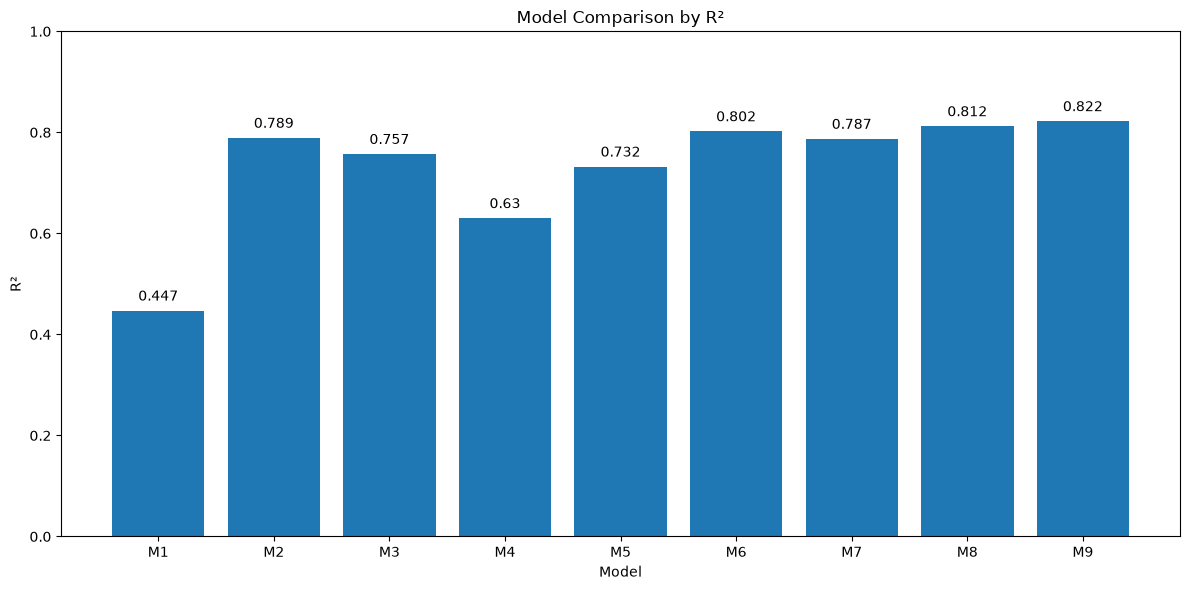

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    model_audit_official["Model_ID"],
    model_audit_official["R_squared"]
)

plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1)

for i, value in enumerate(model_audit_official["R_squared"]):
    plt.text(i, value + 0.02, str(round(value, 3)), ha="center")

plt.tight_layout()
plt.show()

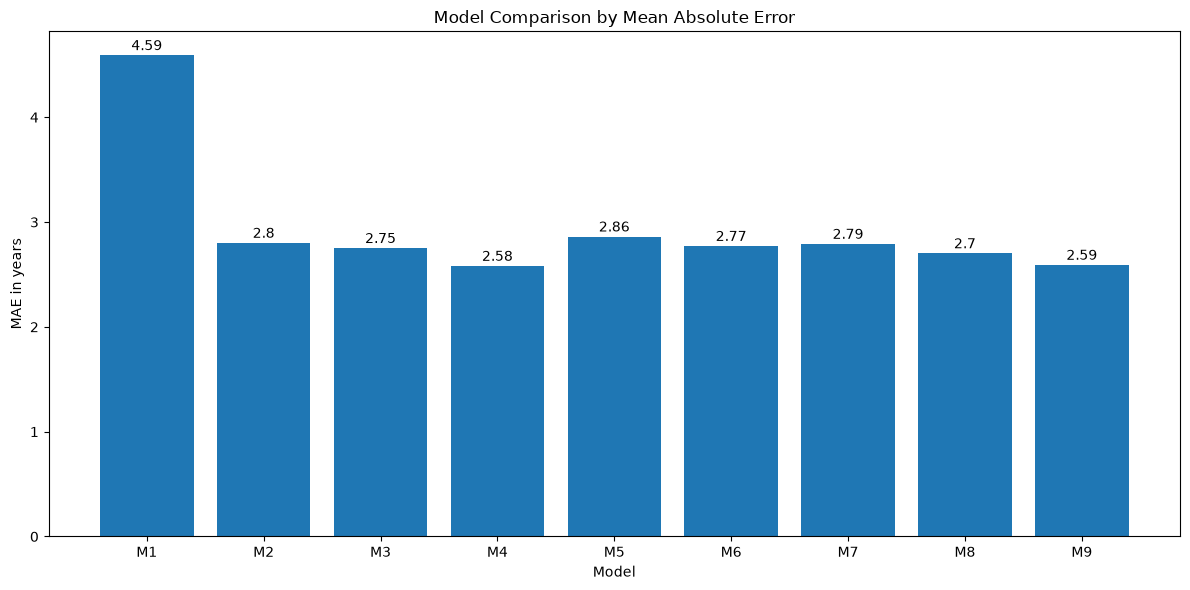

In [53]:
plt.figure(figsize=(12, 6))

plt.bar(
    model_audit_official["Model_ID"],
    model_audit_official["MAE_years"]
)

plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE in years")

for i, value in enumerate(model_audit_official["MAE_years"]):
    plt.text(i, value + 0.05, str(round(value, 2)), ha="center")

plt.tight_layout()
plt.show()

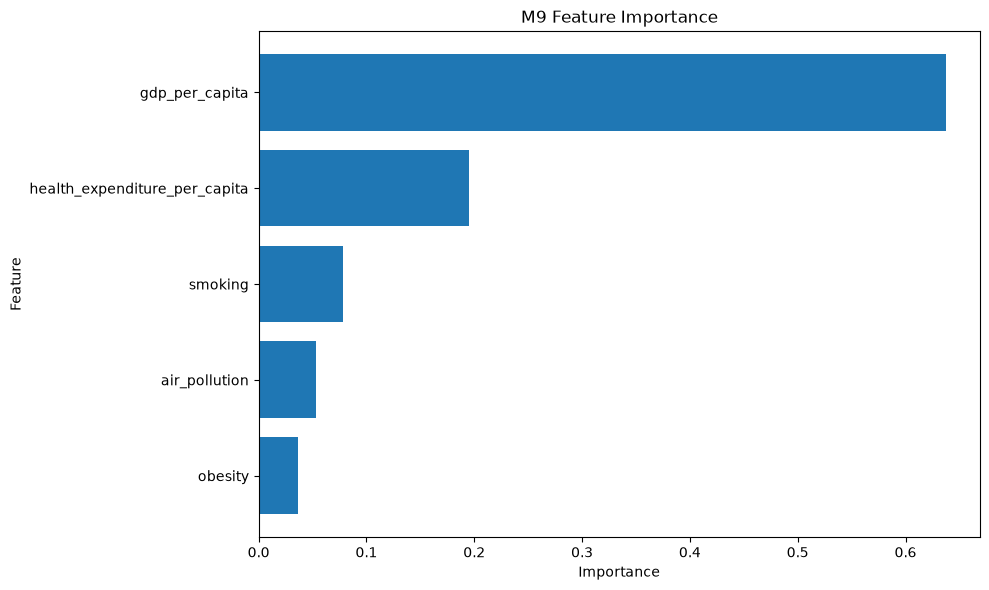

In [54]:
m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"] == "M9"
].sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    m9_importance["Feature"],
    m9_importance["Importance"]
)

plt.title("M9 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

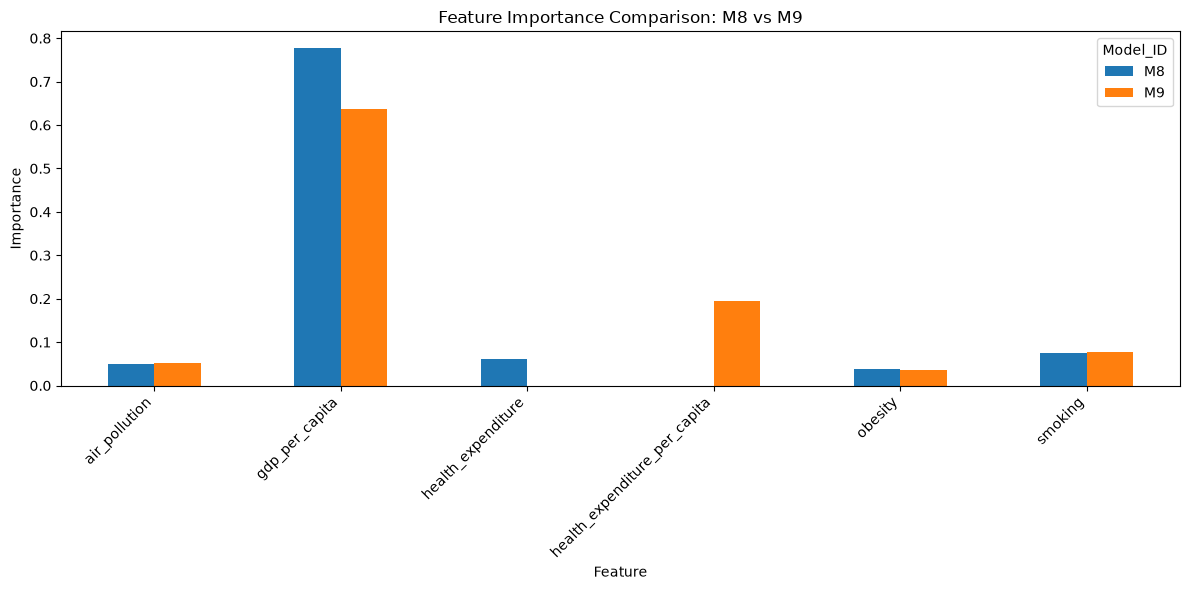

In [55]:
m8_m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"].isin(["M8", "M9"])
].copy()

m8_m9_pivot = m8_m9_importance.pivot(
    index="Feature",
    columns="Model_ID",
    values="Importance"
).fillna(0)

m8_m9_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Feature Importance Comparison: M8 vs M9")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

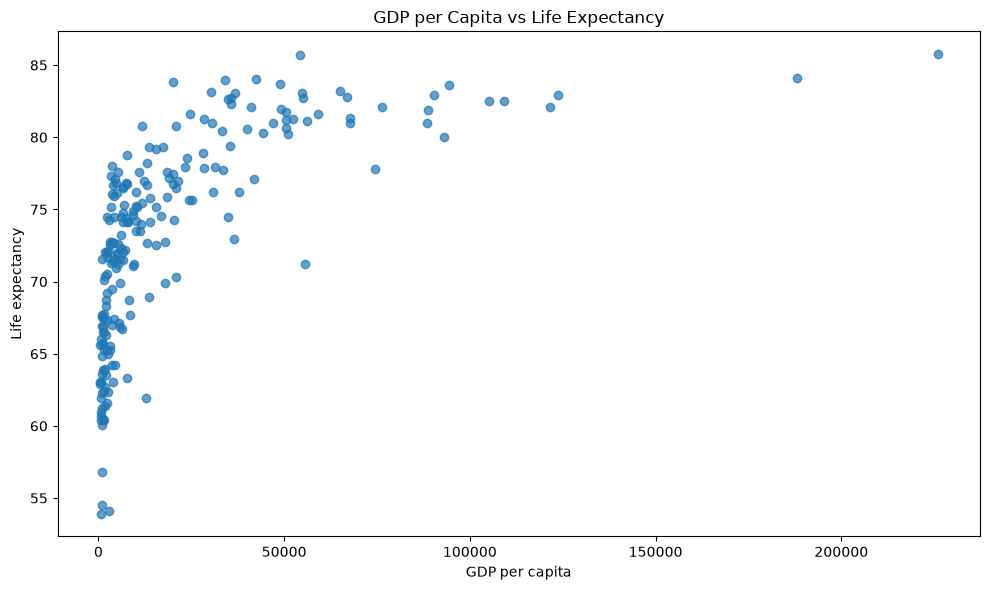

In [56]:
plot_dataset = pd.read_csv("../data/life_expectancy_dataset_v2.csv")

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_dataset["gdp_per_capita"],
    plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

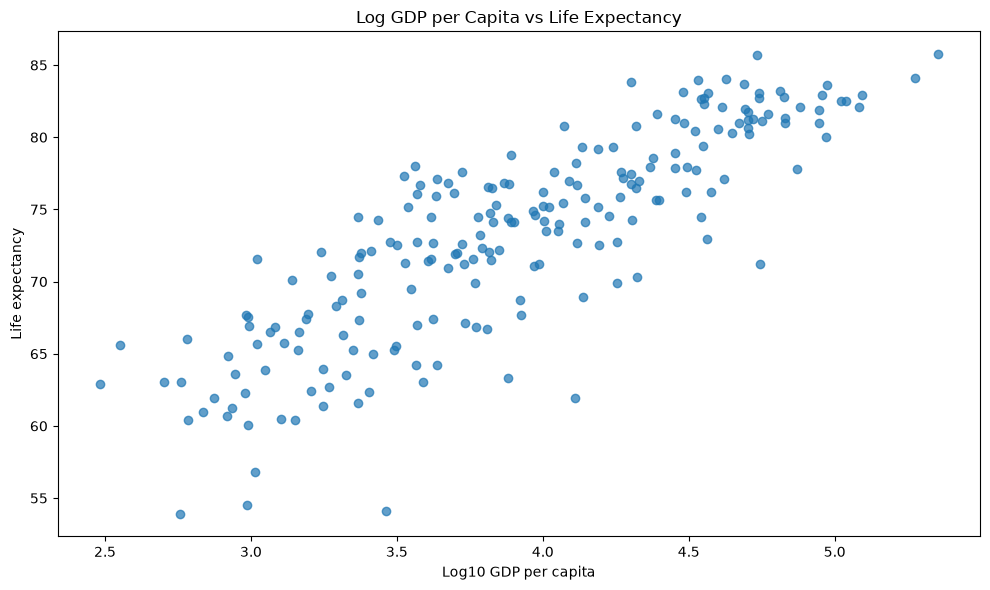

In [57]:
import numpy as np

plot_dataset = plot_dataset.dropna(
    subset=["gdp_per_capita", "life_expectancy"]
).copy()

plot_dataset = plot_dataset[
    plot_dataset["gdp_per_capita"] > 0
].copy()

plot_dataset["log_gdp_per_capita"] = np.log10(plot_dataset["gdp_per_capita"])

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_dataset["log_gdp_per_capita"],
    plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log10 GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

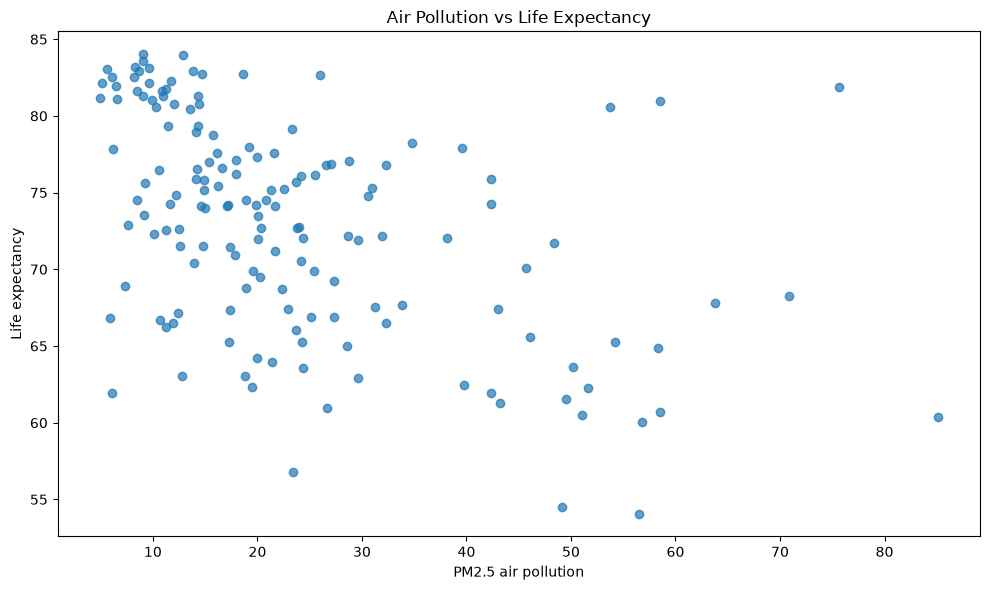

In [58]:
air_pollution_plot_dataset = m9_model_dataset.dropna(
    subset=["air_pollution", "life_expectancy"]
).copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    air_pollution_plot_dataset["air_pollution"],
    air_pollution_plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Air Pollution vs Life Expectancy")
plt.xlabel("PM2.5 air pollution")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

In [59]:
import os

os.makedirs("../reports/figures", exist_ok=True)

print("Figures folder created.")

Figures folder created.


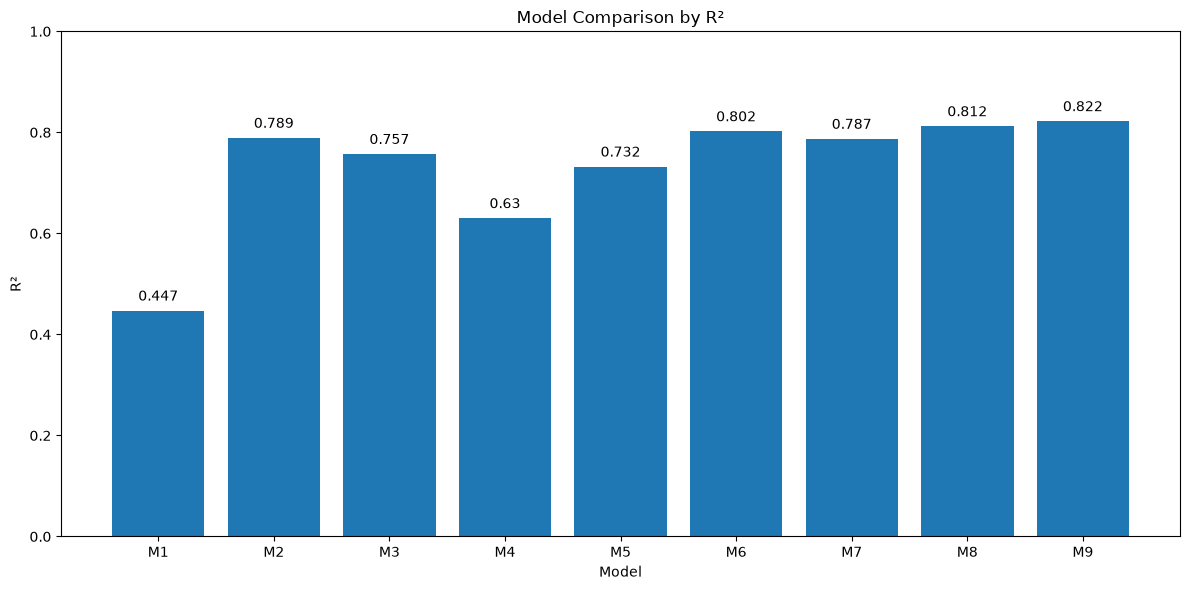

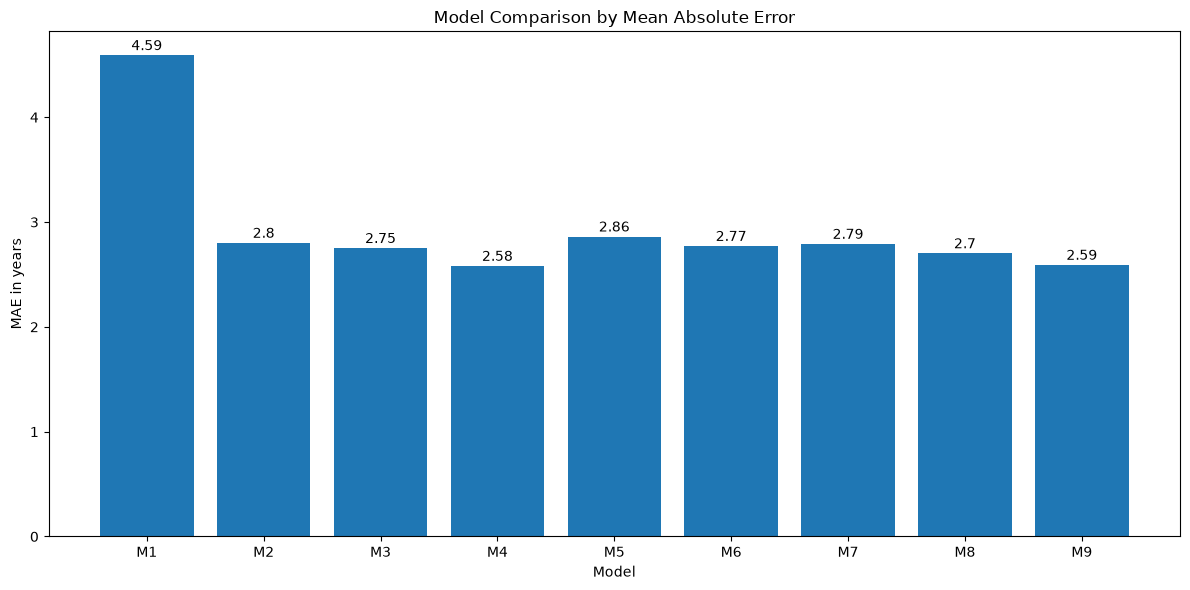

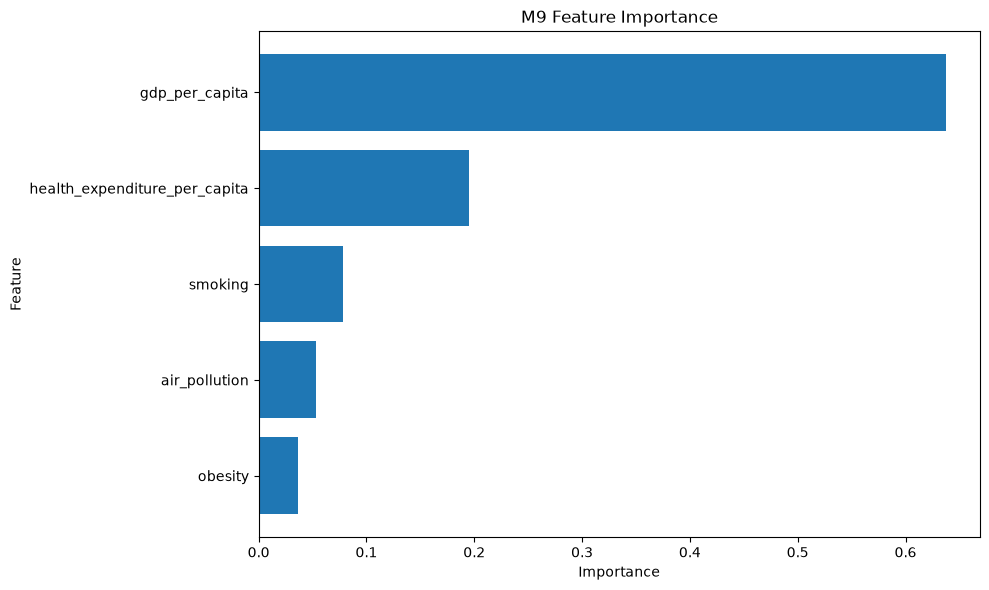

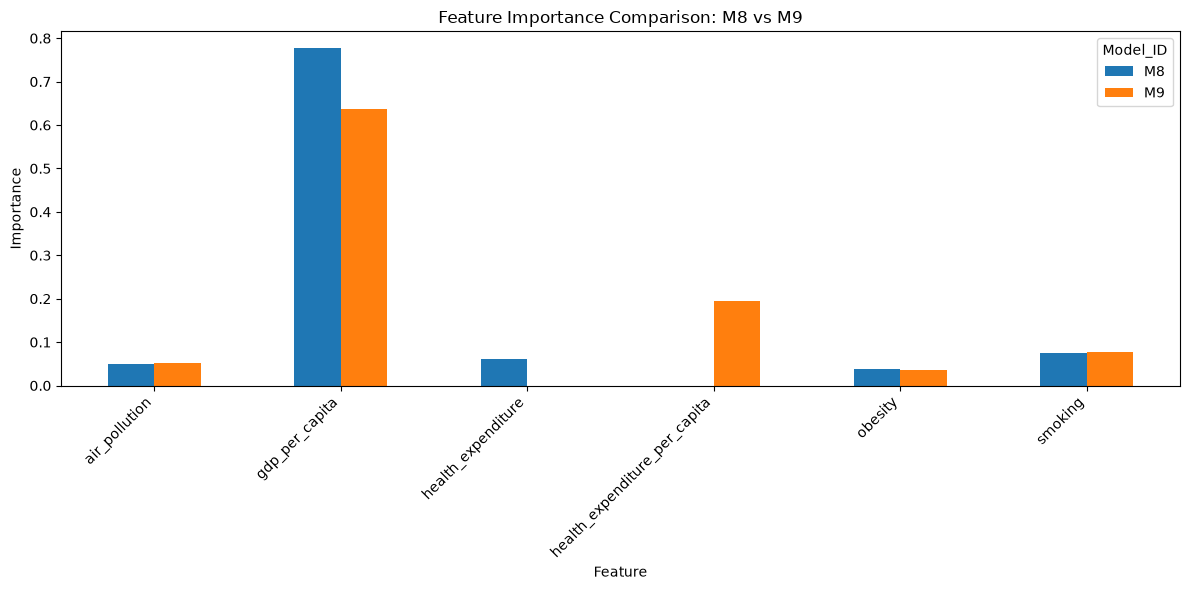

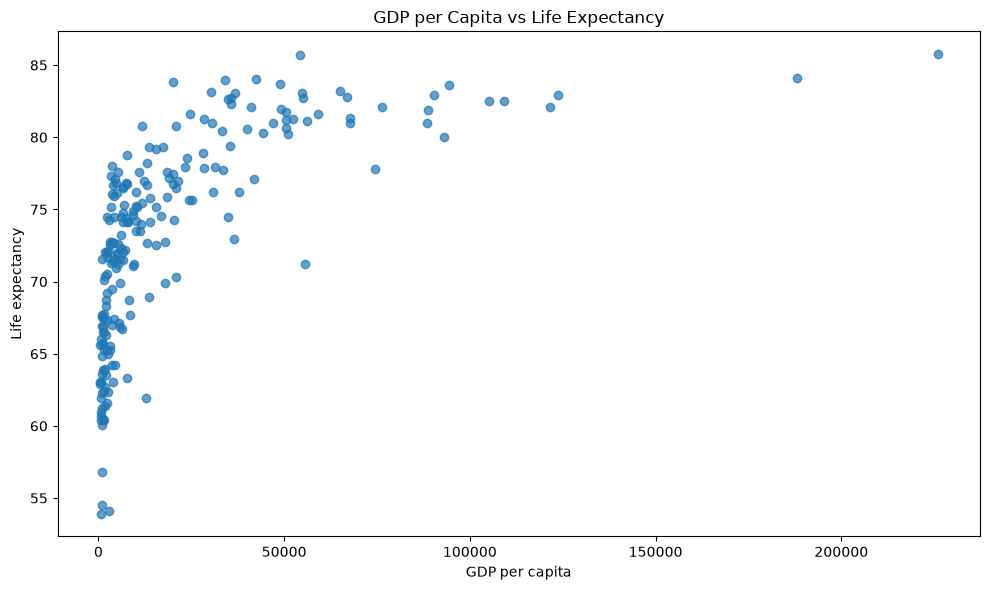

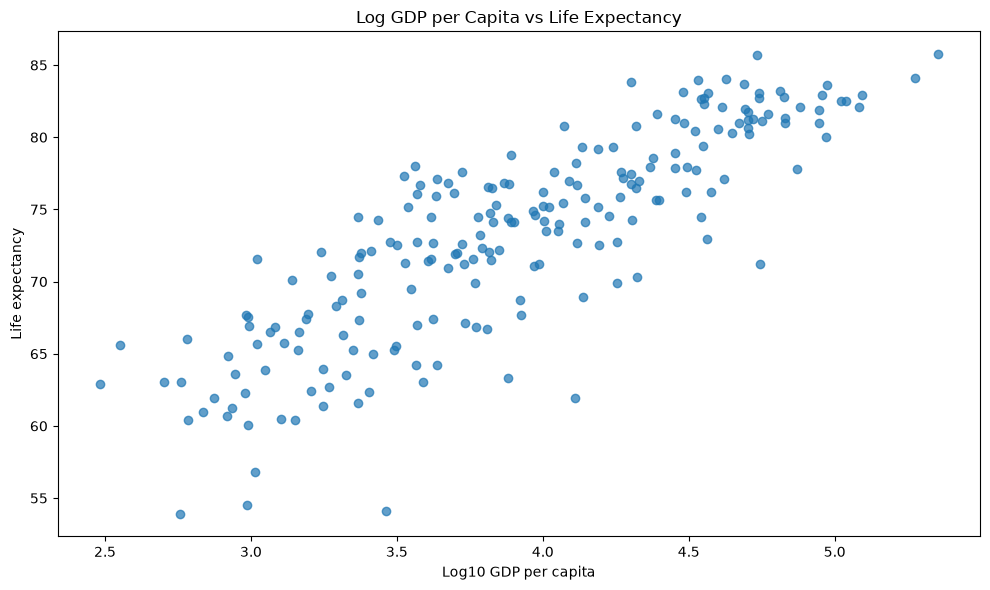

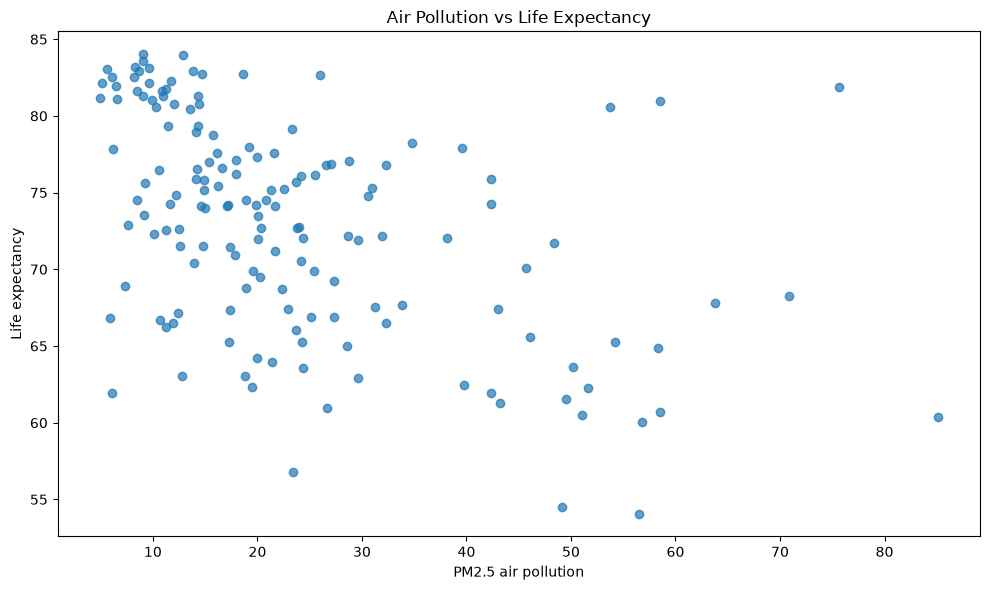

All final figures saved.


In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. R² comparison
plt.figure(figsize=(12, 6))
plt.bar(model_audit_official["Model_ID"], model_audit_official["R_squared"])
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1)

for i, value in enumerate(model_audit_official["R_squared"]):
    plt.text(i, value + 0.02, str(round(value, 3)), ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/model_comparison_r2.png", dpi=300)
plt.show()


# 2. MAE comparison
plt.figure(figsize=(12, 6))
plt.bar(model_audit_official["Model_ID"], model_audit_official["MAE_years"])
plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE in years")

for i, value in enumerate(model_audit_official["MAE_years"]):
    plt.text(i, value + 0.05, str(round(value, 2)), ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/model_comparison_mae.png", dpi=300)
plt.show()


# 3. M9 feature importance
m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"] == "M9"
].sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(m9_importance["Feature"], m9_importance["Importance"])
plt.title("M9 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../reports/figures/m9_feature_importance.png", dpi=300)
plt.show()


# 4. M8 vs M9 feature importance comparison
m8_m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"].isin(["M8", "M9"])
].copy()

m8_m9_pivot = m8_m9_importance.pivot(
    index="Feature",
    columns="Model_ID",
    values="Importance"
).fillna(0)

m8_m9_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Feature Importance Comparison: M8 vs M9")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../reports/figures/m8_vs_m9_feature_importance.png", dpi=300)
plt.show()


# 5. GDP per capita vs life expectancy
plot_dataset = pd.read_csv("../data/life_expectancy_dataset_v2.csv")

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_dataset["gdp_per_capita"],
    plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.savefig("../reports/figures/gdp_vs_life_expectancy.png", dpi=300)
plt.show()


# 6. Log GDP per capita vs life expectancy
plot_dataset = plot_dataset.dropna(
    subset=["gdp_per_capita", "life_expectancy"]
).copy()

plot_dataset = plot_dataset[
    plot_dataset["gdp_per_capita"] > 0
].copy()

plot_dataset["log_gdp_per_capita"] = np.log10(plot_dataset["gdp_per_capita"])

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_dataset["log_gdp_per_capita"],
    plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log10 GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.savefig("../reports/figures/log_gdp_vs_life_expectancy.png", dpi=300)
plt.show()


# 7. Air pollution vs life expectancy
air_pollution_plot_dataset = m9_model_dataset.dropna(
    subset=["air_pollution", "life_expectancy"]
).copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    air_pollution_plot_dataset["air_pollution"],
    air_pollution_plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Air Pollution vs Life Expectancy")
plt.xlabel("PM2.5 air pollution")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.savefig("../reports/figures/air_pollution_vs_life_expectancy.png", dpi=300)
plt.show()

print("All final figures saved.")